# NewFiguresJune — Two New Figures

**Figure 1** (2 rows × 3 cols): Network · Response curves · Loss trajectories  
**Figure 2** (2 rows × 3 cols): Hessian spectrum vs training · Hessian spectrum vs actuation · Participation ratio histograms

Row 0 = local (allosteric) targeted tasks  
Row 1 = global (Poisson/auxetic) targeted tasks

**Note on local stiffness trajectories:** `allosteric_trainer.py` saves `stiffnesses_traj.npy` /
`stiffnesses_traj_steps.npy` at checkpoints. If these files are missing (data generated before
that feature was added), Figure 2 columns 1–2 local panels will be skipped with a warning.

In [3]:
import sys, json, pickle, copy, warnings
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import collections as mc
from matplotlib.colors import Normalize
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

REPO_ROOT = Path('../../../').resolve()
# Add project root so base/, analysis/, training/ packages are importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from base.elastic_network import ElasticNetwork
from base.network_utils import get_square_boundary_nodes
from analysis.susceptibility import compute_physical_hessian_strained
from training.src.training_functions import (
    crf as _crf,
    compute_quasistatic_trajectory_auxetic,
)

print('JAX devices:', jax.devices())
print('Repo root  :', REPO_ROOT)

JAX devices: [CpuDevice(id=0)]
Repo root  : /Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TARGETED_DIR       = REPO_ROOT / 'data' / 'auxetic_nets' / 'targeted_results_sqr'
ALLOSTERIC_TGT_DIR = REPO_ROOT / 'data' / 'allosteric_nets' / 'geometry_targeted'
CACHE_DIR          = REPO_ROOT / '.figure_notebook_cache'
FIGURE_OUT_DIR     = REPO_ROOT / 'figure_data' / 'june_figs'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Physical constants ────────────────────────────────────────────────────────
BOUNDARY_MARGIN = 0.02
FORCE_TYPE      = 'quadratic'
N_EQUIL         = 1
LOCAL_MAX_STRAIN = 1.0
LOCAL_STRAIN2    = 0.5

# ── Cache bypass ──────────────────────────────────────────────────────────────
FORCE_RECOMPUTE = True

# ══════════════════════════════════════════════════════════════════════════════
# USER CHOICES — edit these
# ══════════════════════════════════════════════════════════════════════════════

# Representative tasks for Figure 1 col 0 (network plot) and Figure 2
LOCAL_TASK_ID  = 2;  LOCAL_REAL_ID  = 0
GLOBAL_TASK_ID = 13; GLOBAL_REAL_ID = 0

# Tasks shown in Figure 1 col 1 (response curves) and col 2 (loss trajectories)
LOCAL_RESPONSE_TASKS  = [0, 1, 2, 3, 4]
GLOBAL_RESPONSE_TASKS = list(range(5))   # adjust as desired

# Figure 1 — number of quasi-static steps per response curve
N_STEPS = 100

# Figure 2 col 1: two subtask compression values whose Hessian spectrum is tracked through training
# Set to the actual subtask strain values from the task config (e.g. cfg['compression_strains'])
ES_1 = -0.05   # first subtask compression
ES_2 = -0.15   # second subtask compression
LOCAL_ES_1 = 0.5   # first subtask input strain (local)
LOCAL_ES_2 = 1.0   # second subtask input strain (local)

# Figure 2 col 2: t1 = initial stiffnesses; t2 = argmin(loss) (best step, auto-detected)

# Number of quasi-static steps for Figure 2 Hessian computations
N_STEPS_FIG2 = 100

# Threshold-based timestep selection for training-sweep Hessian computation
N_THRESH_STEPS = 50    # target number of threshold-crossing timesteps
THRESH_EPS_MIN = 1e-3  # final relative-error level (fraction above L_min)

# Tasks to include in Figure 2 col 3 participation ratio histograms
PR_LOCAL_TASKS  = list(range(5))
PR_GLOBAL_TASKS = list(range(22))
PR_REAL_ID      = 0
N_STEPS_PR      = 200   # quasi-static steps for PR computation
N_EPS_BINS      = 20    # number of epsilon bins for PR histogram

print('Configuration loaded.')

Configuration loaded.


In [5]:
# ── Cache helpers (same pattern as AllFigures.ipynb) ─────────────────────────
def _cache_path(key):
    return CACHE_DIR / f'{key}.npz'

def cache_exists(key):
    return _cache_path(key).exists() and not FORCE_RECOMPUTE

def load_cache(key):
    return dict(np.load(_cache_path(key), allow_pickle=True))

def save_cache(key, **arrays):
    np.savez(_cache_path(key), **arrays)

print('Cache helpers defined.')

Cache helpers defined.


In [12]:
# ── Shared helpers (ported from AllFigures.ipynb) ─────────────────────────────

def incmat_to_edges(incmat):
    edges = np.zeros((len(incmat), 2), dtype=int)
    for e, row in enumerate(incmat):
        cols = np.where(np.abs(row) > 0.5)[0]
        edges[e, 0] = int(cols[0])
        edges[e, 1] = int(cols[1])
    return edges

def free_dofs_local(N):
    return np.arange(4, 2 * N)

def free_dofs_global(N, top_nodes, bottom_nodes):
    constrained = np.unique(np.concatenate([
        np.asarray(top_nodes,    dtype=int),
        np.asarray(bottom_nodes, dtype=int),
    ]))
    free_nodes = np.setdiff1d(np.arange(N), constrained)
    return np.sort(np.concatenate([2 * free_nodes, 2 * free_nodes + 1]))

def _sibling_realization_dirs(task_parent, own_dir):
    if not task_parent.is_dir():
        return
    yield own_dir
    for rd in sorted(task_parent.iterdir()):
        if rd.is_dir() and rd != own_dir:
            yield rd

def _geometry_realization_dirs(geom_dir, own_task_parent, own_dir):
    yield own_dir
    for rd in sorted(own_task_parent.iterdir()):
        if rd.is_dir() and rd != own_dir:
            yield rd
    for td in sorted(geom_dir.iterdir()):
        if td.is_dir() and td != own_task_parent:
            for rd in sorted(td.iterdir()):
                if rd.is_dir():
                    yield rd

def load_global_network(task_seed, real_seed, data_dir=None, task_config=None):
    if data_dir is None:
        data_dir = TARGETED_DIR
    
    task_parent = data_dir / f'task_{task_seed:02d}'
    print(task_parent, 'task parent dir')
    own         = task_parent / f'realization_{real_seed:02d}'
    with open(own / 'final_network.pkl', 'rb') as fh:
        net = pickle.load(fh)
    stiffnesses  = np.array(net['stiffnesses'],  dtype=float)
    positions    = np.array(net['positions'],    dtype=float)    if net.get('positions')    is not None else None
    edges        = np.array(net['edges'],        dtype=int)      if net.get('edges')        is not None else None
    rest_lengths = np.array(net['rest_lengths'], dtype=float)    if net.get('rest_lengths') is not None else None
    if positions is None or edges is None:
        for rd in _sibling_realization_dirs(task_parent, own):
            if rd == own:
                continue
            try:
                with open(rd / 'final_network.pkl', 'rb') as fh:
                    alt = pickle.load(fh)
                if positions    is None and alt.get('positions')    is not None:
                    positions    = np.array(alt['positions'],    dtype=float)
                if edges        is None and alt.get('edges')        is not None:
                    edges        = np.array(alt['edges'],        dtype=int)
                if rest_lengths is None and alt.get('rest_lengths') is not None:
                    rest_lengths = np.array(alt['rest_lengths'], dtype=float)
                if positions is not None and edges is not None:
                    break
            except (FileNotFoundError, KeyError):
                continue
    if positions is None:
        raise RuntimeError(f'No positions for global task {task_seed}')
    if edges is None:
        raise RuntimeError(f'No edges for global task {task_seed}')
    if rest_lengths is None:
        d = positions[edges[:, 0]] - positions[edges[:, 1]]
        rest_lengths = np.linalg.norm(d, axis=1)
    top, bottom, left, right = get_square_boundary_nodes(positions, BOUNDARY_MARGIN)
    boundary = dict(top=top, bottom=bottom, left=left, right=right)
    config = task_config
    if config is None:
        for rd in _sibling_realization_dirs(task_parent, own):
            cfg_path = rd / 'task_config.json'
            if cfg_path.exists():
                with open(cfg_path) as fh:
                    config = json.load(fh)
                if config:
                    print(config, 'loaded config')
                    print(rd)
                    break
    if config is None:
        raise RuntimeError(f'No task_config.json for global task {task_seed}')
    network = ElasticNetwork(positions, edges, rest_lengths, stiffnesses)
    return network, boundary, config

def load_local_targeted(task_id, real_id):
    """Load local targeted network from geometry_targeted/task_{task_id}/realization_{real_id}/."""
    data_dir    = ALLOSTERIC_TGT_DIR
    task_parent = data_dir / f'task_{task_id}'
    task_dir    = task_parent / f'realization_{real_id}'
    if not (task_dir / 'stiffnesses.npy').exists():
        return None
    stiffnesses = np.abs(np.load(task_dir / 'stiffnesses.npy').astype(float))
    L0          = np.load(task_dir / 'eq_lengths.npy').astype(float)
    nodes = incmat = None
    for rd in _sibling_realization_dirs(task_parent, task_dir):
        if nodes  is None and (rd / 'nodes.npy').exists():
            nodes  = np.load(rd / 'nodes.npy').astype(float)
        if incmat is None and (rd / 'incidence_matrix.npy').exists():
            incmat = np.load(rd / 'incidence_matrix.npy')
        if nodes is not None and incmat is not None:
            break
    task_vals = None
    for rd in _sibling_realization_dirs(task_parent, task_dir):
        if (rd / 'tasks.txt').exists():
            task_vals = np.loadtxt(rd / 'tasks.txt')
            break
    if nodes is None or incmat is None or task_vals is None:
        return None
    edges = incmat_to_edges(incmat)
    N     = nodes.shape[0]
    fdofs = free_dofs_local(N)
    target_output  = float(np.abs(task_vals[2]))
    target_output2 = float(np.abs(task_vals[1]))
    return dict(
        nodes=nodes, edges=edges, incmat=incmat,
        stiffnesses=stiffnesses, eq_lengths=L0,
        strain_input=LOCAL_MAX_STRAIN, target_output=target_output,
        strain_input2=LOCAL_STRAIN2,   target_output2=target_output2,
        free_dofs=fdofs, N=N,
        task_id=task_id, real_id=real_id,
        task_dir=str(task_dir),
    )

def compute_global_traj(network, compression_strain, boundary, n_steps=N_STEPS):
    net_copy = copy.deepcopy(network)
    return compute_quasistatic_trajectory_auxetic(
        net_copy, compression_strain,
        boundary['top'], boundary['bottom'],
        n_steps=n_steps, verbose=False,
        force_type=FORCE_TYPE, tol=1e-9,
    )

def compute_local_traj(net_dict, max_strain=LOCAL_MAX_STRAIN, n_steps=N_STEPS):
    nodes0   = net_dict['nodes']
    edges_j  = jnp.asarray(net_dict['edges'],       dtype=jnp.int32)
    eq_j     = jnp.asarray(net_dict['eq_lengths'])
    k_j      = jnp.asarray(net_dict['stiffnesses'])
    x0,  y0  = float(nodes0[0, 0]), float(nodes0[0, 1])
    x1i, y1i = float(nodes0[1, 0]), float(nodes0[1, 1])
    d0        = float(np.linalg.norm(nodes0[1] - nodes0[0]))
    src_dof   = jnp.array([0, 2, 1, 3], dtype=jnp.int32)
    traj = [nodes0.copy()]
    pos  = jnp.asarray(nodes0.flatten())
    for step in range(n_steps):
        target  = (step + 1) / n_steps * max_strain
        imposed = jnp.array([x0, x1i + target * d0, y0, y1i])
        for _ in range(N_EQUIL):
            pos = _crf(k_j, edges_j, eq_j, pos, src_dof, imposed)
        traj.append(np.array(pos).reshape(-1, 2))
    return traj

def hessian_modes(positions, stiffnesses, eq_lengths, edges, fdofs):
    H      = compute_physical_hessian_strained(stiffnesses, eq_lengths, edges, positions)
    if fdofs is not None:
        H_free = H[np.ix_(fdofs, fdofs)]
        vals, vecs = np.linalg.eigh(H_free)
        return vals, vecs.T
    else:
        H_free = H
        vals, vecs = np.linalg.eigh(H_free)
        return vals[3:], vecs[3:].T

def compute_analysis(traj, stiffnesses, eq_lengths, edges, fdofs, verbose=False):
    T = len(traj)
    M = len(fdofs)
    spectrum = np.zeros((T, M))
    overlaps = np.zeros((T - 1, M))
    for t in range(T):
        vals, vecs_T = hessian_modes(traj[t], stiffnesses, eq_lengths, edges, fdofs)
        spectrum[t]  = vals
        if t < T - 1:
            dr  = (traj[t + 1] - traj[t]).ravel()[fdofs]
            nrm = float(np.linalg.norm(dr))
            if nrm > 1e-12:
                overlaps[t] = vecs_T @ (dr / nrm)
        if verbose and (t + 1) % 10 == 0:
            print(f'  frame {t+1}/{T}', flush=True)
    return spectrum, overlaps

def participation_ratio(overlaps):
    """PR[t] = (sum_m overlap^4)^{-1} per step. Shape (T-1,)."""
    o4 = overlaps ** 4
    denom = o4.sum(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(denom > 0, 1.0 / denom, np.nan)

def poisson_ratio_along_traj(traj, boundary):
    top, bottom, left, right = (boundary['top'], boundary['bottom'],
                                boundary['left'], boundary['right'])
    pos0 = traj[0]
    h0   = pos0[top, 1].mean() - pos0[bottom, 1].mean()
    w0   = pos0[right, 0].mean() - pos0[left, 0].mean()
    T    = len(traj)
    strains = np.zeros(T)
    nu_vals = np.zeros(T)
    for t, pos in enumerate(traj):
        h = pos[top, 1].mean() - pos[bottom, 1].mean()
        w = pos[right, 0].mean() - pos[left, 0].mean()
        eps_vert  = (h - h0) / h0
        eps_lat   = (w - w0) / w0
        strains[t] = eps_vert
        nu_vals[t] = -eps_lat / eps_vert if abs(eps_vert) > 1e-10 else 0.0
    return strains, nu_vals

def output_strain_along_traj(traj, edges, L0):
    T     = len(traj)
    pos0  = traj[0]
    d23_0 = np.linalg.norm(pos0[3] - pos0[2])
    out_s = np.zeros(T)
    inp_f = np.linspace(0, 1, T)
    for t, pos in enumerate(traj):
        d23      = np.linalg.norm(pos[3] - pos[2])
        out_s[t] = (d23 - d23_0) / d23_0
    return inp_f, out_s

def draw_network(ax, positions, edges, values, cmap='Greys_r',
                 vmin=None, vmax=None, lw=1.5, alpha=0.9,
                 highlight_nodes=None, highlight_colors=None, highlight_size=40):
    log_v = np.log10(np.abs(values) + 1e-14)
    if vmin is None: vmin = np.nanpercentile(log_v, 2)
    if vmax is None: vmax = np.nanpercentile(log_v, 98)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cm   = plt.get_cmap(cmap)
    segs = [positions[e] for e in edges]
    cols = [cm(norm(v)) for v in log_v]
    lc   = mc.LineCollection(segs, colors=cols, linewidths=lw, alpha=alpha)
    ax.add_collection(lc)
    ax.set_xlim(positions[:, 0].min() - 0.05, positions[:, 0].max() + 0.05)
    ax.set_ylim(positions[:, 1].min() - 0.05, positions[:, 1].max() + 0.05)
    ax.set_aspect('equal')
    if highlight_nodes is not None:
        for nodes, color in zip(highlight_nodes, highlight_colors or ['red'] * len(highlight_nodes)):
            ax.scatter(positions[nodes, 0], positions[nodes, 1],
                       s=highlight_size, c=color, zorder=5)
    return lc

print('Shared helpers defined.')

Shared helpers defined.


In [13]:
# ── New helpers specific to this notebook ─────────────────────────────────────

def load_global_stiffness_trajectory(task_id, real_id):
    """Load (T, E) stiffness trajectory and (T,) loss for a global task."""
    d = TARGETED_DIR / f'task_{task_id:02d}' / f'realization_{real_id:02d}'
    k_traj   = np.load(d / 'stiffness_trajectory.npy')  # (T, E)
    loss_traj = np.load(d / 'loss_trajectory.npy')       # (T,)
    return k_traj, loss_traj

def load_local_stiffness_trajectory(task_id, real_id):
    """Load (T_ckpt, E) stiffness trajectory and (T_ckpt,) checkpoint-aligned loss.

    stiffnesses_traj_steps.npy contains 1-indexed step numbers.  The full-resolution
    loss (mse1+mse2) is indexed at (steps-1) so traj[i] and loss[i] refer to the same
    training checkpoint — identical interface to load_global_stiffness_trajectory.
    """
    d = ALLOSTERIC_TGT_DIR / f'task_{task_id}' / f'realization_{real_id}'
    traj_path  = d / 'stiffnesses_traj.npy'
    steps_path = d / 'stiffnesses_traj_steps.npy'
    if not traj_path.exists():
        return None, None, None
    traj  = np.load(traj_path)                    # (T_ckpt, E)
    steps = np.load(steps_path).astype(int)       # (T_ckpt,) 1-indexed step numbers
    mse1_path = d / 'mse1.npy'; mse2_path = d / 'mse2.npy'
    if mse1_path.exists() and mse2_path.exists():
        loss_full = np.load(mse1_path) + np.load(mse2_path)  # (T_full,)
        idx  = np.clip(steps - 1, 0, len(loss_full) - 1)     # 0-indexed
        loss = loss_full[idx]                      # (T_ckpt,) aligned to traj
    else:
        loss = None
    return traj, steps, loss

def hessian_eigs_global(stiffnesses, net_template, compression, boundary, fdofs, n_steps=N_STEPS_FIG2):
    """Eigenvalues of free-DOF Hessian at equilibrium under `compression`, using given stiffnesses."""
    net = copy.deepcopy(net_template)
    net.stiffnesses = np.asarray(stiffnesses, dtype=float)
    traj = compute_global_traj(net, compression, boundary, n_steps=n_steps)
    pos_eq = traj[-1]
    vals, _ = hessian_modes(pos_eq, np.asarray(stiffnesses, dtype=float),
                            net_template.rest_lengths, net_template.edges, fdofs)
    return vals

def hessian_eigs_local(stiffnesses, net_dict_template, max_strain, fdofs, n_steps=N_STEPS_FIG2, pos_eq=None):
    """Eigenvalues of free-DOF Hessian at equilibrium under `max_strain`, using given stiffnesses."""
    nd  = {**net_dict_template, 'stiffnesses': np.asarray(stiffnesses, dtype=float)}
    if pos_eq is None:
        traj = compute_local_traj(nd, max_strain=max_strain, n_steps=n_steps)
    else:
        traj = [pos_eq]
    vals, _ = hessian_modes(traj[-1], np.asarray(stiffnesses, dtype=float),
                            nd['eq_lengths'], nd['edges'], fdofs)
    return vals

print('New helpers defined.')

def select_loss_threshold_steps(loss, n_steps=50, eps_min=1e-3):
    """Return training step indices at log-spaced loss thresholds, guaranteed monotone.

    Works on the running-minimum subsequence (times when loss sets a new record low)
    so L[selected] is strictly decreasing.  t_star (argmin) is always the last step.
    """
    L = np.asarray(loss)
    t_star = int(np.argmin(L))
    L_d = L[:t_star + 1]
    L_min = max(float(L_d[-1]), 1e-300)

    # Build strictly-decreasing running-minimum subsequence (t=0 always included)
    nm_idx = [0]
    run_min = float(L_d[0])
    for t in range(1, len(L_d)):
        if float(L_d[t]) < run_min:   # strict < avoids float-tie duplicates
            run_min = float(L_d[t])
            nm_idx.append(t)
    nm_idx = np.array(nm_idx)          # original-time indices of new-record lows
    L_nm  = L_d[nm_idx]               # strictly non-increasing losses at those times
    rel   = (L_nm - L_min) / L_min    # relative excess above global minimum

    if len(rel) == 0 or rel[0] <= 0:
        return np.array([t_star])

    thresholds = np.logspace(np.log10(rel[0] + 1e-300), np.log10(eps_min), n_steps)
    selected_nm = []; ptr = 0
    for th in thresholds:
        hits = np.where((np.arange(len(rel)) >= ptr) & (rel <= th))[0]
        if hits.size > 0:
            selected_nm.append(int(hits[0]))
            ptr = hits[0] + 1

    # Map back to original time axis
    idx = np.unique(np.append(nm_idx[selected_nm], t_star))
    print(f'    threshold steps: {len(idx)} (target {n_steps}, new-record lows={len(nm_idx)}, t_star={t_star})')
    return idx




New helpers defined.


## Figure 1 — Network · Response · Loss

In [14]:
# ── Figure 1: load / compute all data (cached) ────────────────────────────────
print('=== Loading local data (Figure 1) ===')

# Representative local network (for col 0 network plot)
local_rep = load_local_targeted(LOCAL_TASK_ID, LOCAL_REAL_ID)
assert local_rep is not None, f'Could not load local task {LOCAL_TASK_ID} real {LOCAL_REAL_ID}'

# Representative global network (for col 0 network plot)
global_rep_net, global_rep_bnd, global_rep_cfg = load_global_network(
    GLOBAL_TASK_ID, GLOBAL_REAL_ID, data_dir=TARGETED_DIR)
N_global = len(global_rep_net.positions)
global_rep_fdofs = free_dofs_global(N_global, global_rep_bnd['top'], global_rep_bnd['bottom'])

# For global col 0: use stiffness at argmin(loss) as 'best'
k_traj_rep, loss_traj_rep = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
global_best_k = k_traj_rep[np.argmin(loss_traj_rep)]

print(f'  Global rep: {N_global} nodes, {len(global_rep_net.edges)} edges, '
      f'best step={np.argmin(loss_traj_rep)}/{len(loss_traj_rep)}')
print(f'  Local rep : {local_rep["N"]} nodes, {len(local_rep["edges"])} edges')

# ── Local response curves ──────────────────────────────────────────────────────
print('\n=== Local response tasks ===')
local_response_data = []
for task_id in LOCAL_RESPONSE_TASKS:
    key = f'june_fig1_local_t{task_id}_r{LOCAL_REAL_ID}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        local_response_data.append({'task_id': task_id, **d})
        print(f'  task {task_id}: loaded from cache')
        continue
    nd = load_local_targeted(task_id, LOCAL_REAL_ID)
    if nd is None:
        print(f'  task {task_id}: MISSING — skipped')
        continue
    traj = compute_local_traj(nd, n_steps=N_STEPS)
    inp_f, out_s = output_strain_along_traj(traj, nd['edges'], nd['eq_lengths'])
    t_dir = ALLOSTERIC_TGT_DIR / f'task_{task_id}' / f'realization_{LOCAL_REAL_ID}'
    mse1  = np.load(t_dir / 'mse1.npy')
    mse2  = np.load(t_dir / 'mse2.npy')
    loss  = mse1 + mse2
    T_loss = len(loss)
    save_cache(key,
               inp_fracs=inp_f, out_strains=out_s,
               stiffnesses=nd['stiffnesses'],
               target_outputs=np.array([nd['target_output'], nd['target_output2']]),
               strain_inputs=np.array([nd['strain_input'], nd['strain_input2']]),
               loss=loss, T_loss=np.array(T_loss))
    d = load_cache(key)
    local_response_data.append({'task_id': task_id, **d})
    print(f'  task {task_id}: computed and cached')

# ── Global response curves ─────────────────────────────────────────────────────
print('\n=== Global response tasks ===')
global_response_data = []
for task_id in GLOBAL_RESPONSE_TASKS:
    key = f'june_fig1_global_t{task_id:02d}_r{GLOBAL_REAL_ID:02d}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        global_response_data.append({'task_id': task_id, **d})
        print(f'  task {task_id:02d}: loaded from cache')
        continue
    try:
        net, bnd, cfg = load_global_network(task_id, GLOBAL_REAL_ID, data_dir=TARGETED_DIR)
    except Exception as e:
        print(f'  task {task_id:02d}: LOAD ERROR — {e}')
        continue
    comp_strains  = np.array(cfg['compression_strains'])
    target_nus    = np.array(cfg['target_poisson_ratios'])
    n_sub         = len(comp_strains)
    # Compute trajectory for each subtask compression
    all_strains, all_nus = [], []
    for cs in comp_strains:
        traj = compute_global_traj(net, cs, bnd, n_steps=N_STEPS)
        strains, nus = poisson_ratio_along_traj(traj, bnd)
        all_strains.append(strains)
        all_nus.append(nus)
    t_dir = TARGETED_DIR / f'task_{task_id:02d}' / f'realization_{GLOBAL_REAL_ID:02d}'
    loss  = np.load(t_dir / 'loss_trajectory.npy')
    k_traj_g, _ = load_global_stiffness_trajectory(task_id, GLOBAL_REAL_ID)
    best_k = k_traj_g[np.argmin(loss)]
    save_cache(key,
               best_stiffnesses=best_k,
               comp_strains=comp_strains, target_nus=target_nus,
               traj_strains=np.array(all_strains),   # (n_sub, T)
               traj_nus=np.array(all_nus),            # (n_sub, T)
               loss=loss)
    d = load_cache(key)
    global_response_data.append({'task_id': task_id, **d})
    print(f'  task {task_id:02d}: computed and cached')

print('\nFigure 1 data ready.')

=== Loading local data (Figure 1) ===
/Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/auxetic_nets/targeted_results_sqr/task_13 task parent dir
{'task_seed': 13, 'packing_seed': 42, 'n_nodes': 100, 'n_strain_steps': 400, 'compression_strains': [-0.3, -0.15], 'target_poisson_ratios': [-0.6, -0.225]} loaded config
/Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/auxetic_nets/targeted_results_sqr/task_13/realization_00
  Global rep: 98 nodes, 194 edges, best step=174/5000
  Local rep : 87 nodes, 253 edges

=== Local response tasks ===


ERROR:2026-06-23 11:36:24,762:jax._src.debugging:95: jax.debug.callback failed
Traceback (most recent call last):
  File "/Users/fmartins/miniconda3/envs/auxetic_nets/lib/python3.11/site-packages/jax/_src/debugging.py", line 93, in debug_callback_impl
    callback(*args)
  File "/Users/fmartins/miniconda3/envs/auxetic_nets/lib/python3.11/site-packages/jax/_src/debugging.py", line 278, in _flat_callback
    callback(*args, **kwargs)
  File "/Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/training/src/training_functions.py", line 417, in _warn_if_not_converged
    if float(gnorm) / n_dof >= tol:
       ^^^^^^^^^^^^
  File "/Users/fmartins/miniconda3/envs/auxetic_nets/lib/python3.11/site-packages/jax/_src/array.py", line 299, in __float__
    return self._value.__float__()
           ^^^^^^^^^^^
  File "/Users/fmartins/miniconda3/envs/auxetic_nets/lib/python3.11/site-packages/jax/_src/profiler.py", line 333, in wrapper
    return func(*args, **kwargs)
           ^^^^^

KeyboardInterrupt: 

    threshold steps: 47 (target 50, new-record lows=3920, t_star=4972)
    threshold steps: 51 (target 50, new-record lows=4432, t_star=4999)
    threshold steps: 35 (target 50, new-record lows=4593, t_star=13721)
    threshold steps: 45 (target 50, new-record lows=3463, t_star=4997)
    threshold steps: 37 (target 50, new-record lows=3944, t_star=14990)
    threshold steps: 23 (target 50, new-record lows=41, t_star=3993)
    threshold steps: 19 (target 50, new-record lows=53, t_star=3312)
    threshold steps: 25 (target 50, new-record lows=79, t_star=4903)
    threshold steps: 23 (target 50, new-record lows=63, t_star=3894)
    threshold steps: 19 (target 50, new-record lows=53, t_star=2816)


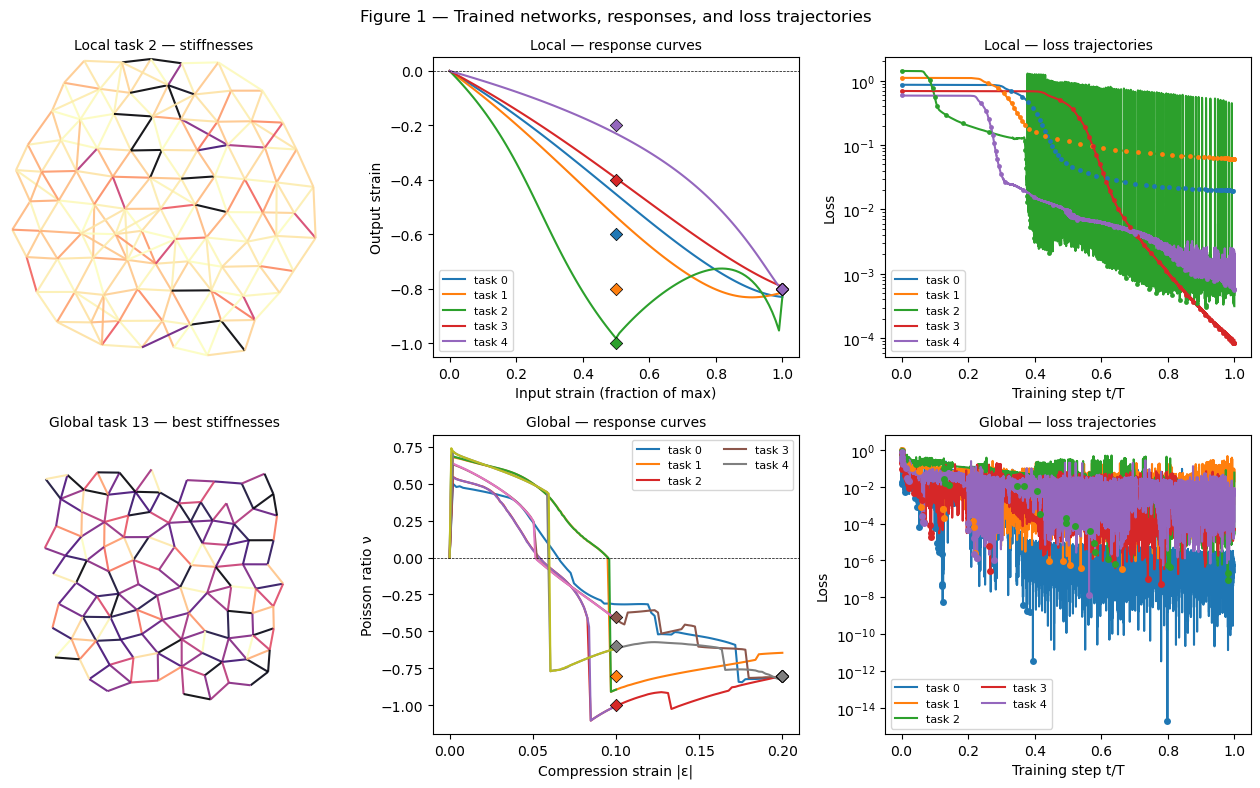

Figure 1 saved.


In [20]:
# ── Figure 1: plot ─────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(13, 8))
fig1.suptitle('Figure 1 — Trained networks, responses, and loss trajectories', fontsize=12)

# ── Col 0: Network with best stiffness edge colors (magma) ───────────────────
# Row 0: local representative
ax = axes1[0, 0]
draw_network(ax, local_rep['nodes'], local_rep['edges'], local_rep['stiffnesses'], cmap='magma')
ax.set_title(f'Local task {LOCAL_TASK_ID} — stiffnesses', fontsize=10)
ax.axis('off')

# Row 1: global representative (best stiffnesses = argmin loss)
ax = axes1[1, 0]
draw_network(ax, global_rep_net.positions, global_rep_net.edges, global_best_k, cmap='magma')
ax.set_title(f'Global task {GLOBAL_TASK_ID} — best stiffnesses', fontsize=10)
ax.axis('off')

# ── Col 1: Response curves ────────────────────────────────────────────────────
# Row 0: local — output strain vs input strain fraction
ax = axes1[0, 1]
for d in local_response_data:
    task_id = int(d['task_id'])
    inp_f   = d['inp_fracs']
    out_s   = d['out_strains']
    targets = d['target_outputs']   # [target_full, target_half]
    s_ins   = d['strain_inputs']    # [1.0, 0.5]
    line,   = ax.plot(inp_f, out_s, alpha=1, label=f'task {task_id}')
    c = line.get_color()
    # Mark targets: (strain_input_frac=1.0, target_full) and (0.5, target_half)
    ax.scatter([1.0, 0.5], [-np.abs(float(targets[0])), -np.abs(float(targets[1]))],
               marker='D', s=40, color=c, zorder=5, linewidths=0.5, edgecolors='k')
ax.set_xlabel('Input strain (fraction of max)', fontsize=10)
ax.set_ylabel('Output strain', fontsize=10)
ax.set_title('Local — response curves', fontsize=10)
ax.legend(fontsize=8)
ax.axhline(0, c='k', lw=0.5, ls='--')

# Row 1: global — Poisson ratio vs |compression strain|
ax = axes1[1, 1]
for d in global_response_data:
    task_id     = int(d['task_id'])
    comp_strains = d['comp_strains']   # (n_sub,)
    target_nus   = d['target_nus']     # (n_sub,)
    traj_strains = d['traj_strains']   # (n_sub, T)
    traj_nus     = d['traj_nus']       # (n_sub, T)
    task_color   = None
    for si, (cs, tp) in enumerate(zip(comp_strains, target_nus)):
        label = f'task {task_id}' if si == 0 else None
        line, = ax.plot(np.abs(traj_strains[si]), traj_nus[si], alpha=1, label=label)
        if task_color is None:
            task_color = line.get_color()
        ax.scatter([np.abs(cs)], [-np.abs(tp)], marker='D', s=40, color=task_color,
                   zorder=5, linewidths=0.5, edgecolors='k')
ax.set_xlabel('Compression strain |ε|', fontsize=10)
ax.set_ylabel('Poisson ratio ν', fontsize=10)
ax.set_title('Global — response curves', fontsize=10)
ax.legend(fontsize=8, ncol=2)
ax.axhline(0, c='k', lw=0.5, ls='--')

# ── Col 2: Loss trajectories (rescaled t/T) ───────────────────────────────────
# Row 0: local
ax = axes1[0, 2]
for d in local_response_data:
    task_id = int(d['task_id'])
    loss    = d['loss']
    T_loss  = len(loss)
    t_norm  = np.arange(T_loss) / max(T_loss - 1, 1)
    line, = ax.plot(t_norm, loss, alpha=1, label=f'task {task_id}')
    t_sel = select_loss_threshold_steps(loss, N_THRESH_STEPS, THRESH_EPS_MIN)
    ax.scatter(t_sel / max(T_loss - 1, 1), loss[t_sel],
               s=12, color=line.get_color(), zorder=5, linewidths=0)
ax.set_xlabel('Training step t/T', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Local — loss trajectories', fontsize=10)
ax.set_yscale('log')
ax.legend(fontsize=8)

# Row 1: global
ax = axes1[1, 2]
for d in global_response_data:
    task_id = int(d['task_id'])
    loss    = d['loss']
    T_loss  = len(loss)
    t_norm  = np.arange(T_loss) / max(T_loss - 1, 1)
    line, = ax.plot(t_norm, loss, alpha=1, label=f'task {task_id}')
    t_sel = select_loss_threshold_steps(loss, N_THRESH_STEPS, THRESH_EPS_MIN)
    ax.scatter(t_sel / max(T_loss - 1, 1), loss[t_sel],
               s=25, color=line.get_color(), zorder=5, linewidths=0)
ax.set_xlabel('Training step t/T', fontsize=10)
ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Global — loss trajectories', fontsize=10)
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)

fig1.tight_layout()
plt.show()
fig1.savefig(FIGURE_OUT_DIR / 'fig1_network_response_loss.pdf', bbox_inches='tight', dpi=150)
print('Figure 1 saved.')

    threshold steps: 19 (target 50, new-record lows=19, t_star=174)
✓ Monotonically decreasing (19 steps, L: 1.222e-01 → 1.725e-08)


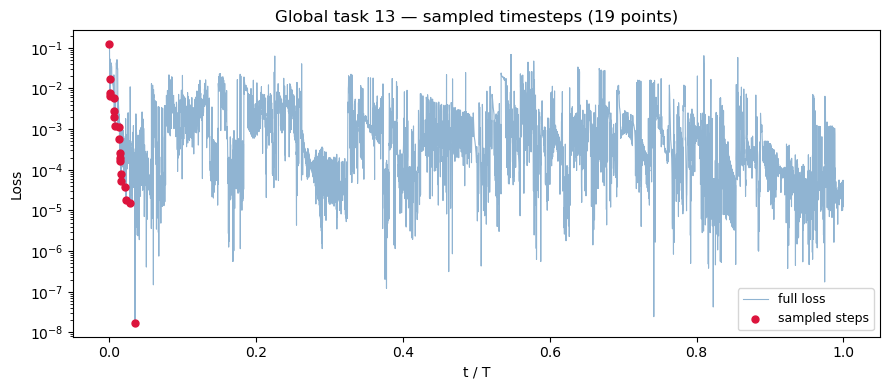

In [21]:
# ── Debug: sampled loss timesteps (monotonicity check) ───────────────────────
_, loss_g_dbg = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
t_sel_dbg = select_loss_threshold_steps(loss_g_dbg, N_THRESH_STEPS, THRESH_EPS_MIN)
T_dbg = len(loss_g_dbg)

fig_dbg, ax_dbg = plt.subplots(figsize=(9, 4))
t_all = np.arange(T_dbg) / max(T_dbg - 1, 1)
ax_dbg.plot(t_all, loss_g_dbg, lw=0.8, color='steelblue', alpha=0.6, label='full loss')
ax_dbg.scatter(t_sel_dbg / max(T_dbg - 1, 1), loss_g_dbg[t_sel_dbg],
               s=25, color='crimson', zorder=5, label='sampled steps')
ax_dbg.set_yscale('log')
ax_dbg.set_xlabel('t / T')
ax_dbg.set_ylabel('Loss')
ax_dbg.set_title(f'Global task {GLOBAL_TASK_ID} — sampled timesteps ({len(t_sel_dbg)} points)')
ax_dbg.legend(fontsize=9)

# Monotonicity check
L_sel = loss_g_dbg[t_sel_dbg]
diffs = np.diff(L_sel)
n_violations = int(np.sum(diffs >= 0))
if n_violations == 0:
    print(f'✓ Monotonically decreasing ({len(t_sel_dbg)} steps, '
          f'L: {L_sel[0]:.3e} → {L_sel[-1]:.3e})')
else:
    print(f'✗ {n_violations} non-monotone jump(s):')
    for i in np.where(diffs >= 0)[0]:
        print(f'  step {t_sel_dbg[i]} L={L_sel[i]:.3e} → step {t_sel_dbg[i+1]} L={L_sel[i+1]:.3e}')

plt.tight_layout(); plt.show()


## Figure 2 — Hessian Spectrum · Participation Ratio

**Col 0** — Hessian eigenvalues vs training step, at two fixed subtask compressions (ES_1, ES_2 / LOCAL_ES_1, LOCAL_ES_2).  
**Col 1** — Hessian eigenvalues vs actuation strain, at two fixed training timesteps (T_1_FRAC, T_2_FRAC).  
**Col 2** — Overlapping histograms of PR(trained,ε) / PR(initial,ε), colored by ε (viridis).

> **Local stiffness trajectory note:** requires `stiffnesses_traj.npy` / `stiffnesses_traj_steps.npy`
> saved by `allosteric_trainer.py`. If missing (pre-feature data), cols 0–1 local row will be blank.

In [22]:
from tqdm import tqdm
# ── Figure 2: compute Hessian spectrum data (cached) ─────────────────────────
print('=== Figure 2: Hessian spectrum through training ===')

# ── GLOBAL col 0: H(t, ES_1) and H(t, ES_2) throughout training ───────────────
key_g_train = f'june_fig2_hess_train_global_t{GLOBAL_TASK_ID:02d}_r{GLOBAL_REAL_ID:02d}_v2'
k_traj_g, loss_g = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
if cache_exists(key_g_train) and not FORCE_RECOMPUTE:
    g_train = load_cache(key_g_train)
    print(f'  Global training Hessian: loaded from cache ({len(g_train["t_indices"])} points)')
else:
    T_g       = len(k_traj_g)
    t_indices = select_loss_threshold_steps(loss_g, N_THRESH_STEPS, THRESH_EPS_MIN)
    n_t       = len(t_indices)
    n_modes   = len(global_rep_fdofs)
    eigs_es1  = np.full((n_t, n_modes), np.nan)
    eigs_es2  = np.full((n_t, n_modes), np.nan)
    print(f'  Global training Hessian: computing {n_t} timesteps × 2 compressions...')
    for i, t_idx in tqdm(enumerate(t_indices), total=n_t):
        k_t = k_traj_g[t_idx]
        # try:
        eigs_es1[i] = hessian_eigs_global(k_t, global_rep_net, ES_1,
                                            global_rep_bnd, global_rep_fdofs)
        eigs_es2[i] = hessian_eigs_global(k_t, global_rep_net, ES_2,
                                            global_rep_bnd, global_rep_fdofs)
    save_cache(key_g_train, t_indices=t_indices, T_total=np.array(T_g),
               eigs_es1=eigs_es1, eigs_es2=eigs_es2,
               ES_1=np.array(ES_1), ES_2=np.array(ES_2))
    g_train = load_cache(key_g_train)
    print('  Global training Hessian: done and cached.')

=== Figure 2: Hessian spectrum through training ===
    threshold steps: 19 (target 50, new-record lows=19, t_star=174)
  Global training Hessian: computing 19 timesteps × 2 compressions...


100%|██████████| 19/19 [00:17<00:00,  1.09it/s]

  Global training Hessian: done and cached.


In [23]:
from tqdm import tqdm
# ── GLOBAL col 1: H(t_1, es) and H(t_2, es) throughout actuation ──────────────
key_g_act = f'june_fig2_hess_act_global_t{GLOBAL_TASK_ID:02d}_r{GLOBAL_REAL_ID:02d}_v3'
if cache_exists(key_g_act) and not FORCE_RECOMPUTE:
    g_act = load_cache(key_g_act)
    print(f'  Global actuation Hessian: loaded from cache')
else:
    T_g       = len(k_traj_g)
    t_indices = select_loss_threshold_steps(loss_g, N_THRESH_STEPS, THRESH_EPS_MIN)
    n_t       = len(t_indices)
    n_modes   = len(global_rep_fdofs)
    t_1, t_2 = t_indices[0], t_indices[-1]
    k_t1 = k_traj_g[t_1]
    k_t2 = k_traj_g[t_2]
    max_cs = float(np.max(np.abs(global_rep_cfg['compression_strains'])))
    comp_range = np.linspace(0, max_cs, N_STEPS_FIG2 + 1)[1:]  # skip zero
    n_cs   = len(comp_range)
    n_modes = len(global_rep_fdofs)
    eigs_t1 = np.full((n_cs, n_modes), np.nan)
    eigs_t2 = np.full((n_cs, n_modes), np.nan)
    print(f'  Global actuation Hessian: computing {n_cs} compressions × 2 timesteps '
          f'(t1={t_1}, t2={t_2})...')
    for i, cs in tqdm(enumerate(comp_range), total=n_cs):
        # try:  
        eigs_t1[i] = hessian_eigs_global(k_t1, global_rep_net, -cs,
                                            global_rep_bnd, global_rep_fdofs)
        eigs_t2[i] = hessian_eigs_global(k_t2, global_rep_net, -cs,
                                            global_rep_bnd, global_rep_fdofs)

    assert np.isnan(eigs_t2).any() == False and np.isnan(eigs_t1).any() == False, 'NaNs in Hessian eigenvalues'
    save_cache(key_g_act, comp_range=comp_range,
               eigs_t1=eigs_t1, eigs_t2=eigs_t2,
               t_1=np.array(t_1), t_2=np.array(t_2), T_total=np.array(T_g))
    g_act = load_cache(key_g_act)
    print('  Global actuation Hessian: done and cached.')

    threshold steps: 19 (target 50, new-record lows=19, t_star=174)
  Global actuation Hessian: computing 100 compressions × 2 timesteps (t1=0, t2=174)...


100%|██████████| 100/100 [01:58<00:00,  1.19s/it]

  Global actuation Hessian: done and cached.


In [ ]:
from tqdm import tqdm

# ── LOCAL col 0 & 1 ──────────────────────────────────────────────────────────────
local_traj_k, local_traj_steps, local_traj_loss = load_local_stiffness_trajectory(
    LOCAL_TASK_ID, LOCAL_REAL_ID)
local_rep_fdofs = local_rep['free_dofs']

# LOCAL col 0: H(t, LOCAL_ES_1) and H(t, LOCAL_ES_2) throughout training
key_l_train = f'june_fig2_hess_train_local_t{LOCAL_TASK_ID}_r{LOCAL_REAL_ID}_v2'
if cache_exists(key_l_train):
    l_train = load_cache(key_l_train)
    print(f'  Local training Hessian: loaded from cache')
else:
    T_l      = len(local_traj_k)
    t_indices_l = select_loss_threshold_steps(local_traj_loss, N_THRESH_STEPS, THRESH_EPS_MIN)
    n_t_l    = len(t_indices_l)
    n_modes_l = len(local_rep_fdofs)
    eigs_es1_l = np.full((n_t_l, n_modes_l), np.nan)
    eigs_es2_l = np.full((n_t_l, n_modes_l), np.nan)
    print(f'  Local training Hessian: computing {n_t_l} checkpoints × 2 strains...')
    for i, t_idx in tqdm(enumerate(t_indices_l), total=n_t_l):
        k_t = local_traj_k[t_idx]
        # try:
        eigs_es1_l[i] = hessian_eigs_local(k_t, local_rep, LOCAL_ES_1, local_rep_fdofs)
        eigs_es2_l[i] = hessian_eigs_local(k_t, local_rep, LOCAL_ES_2, local_rep_fdofs)
        # except Exception as e:
            # print(f'    t={t_idx}: error — {e}')
        if (i + 1) % 10 == 0:
            print(f'    {i+1}/{n_t_l}', flush=True)
    # Steps are checkpoint step numbers; normalize by total loss length
    t_norm_l = local_traj_steps[t_indices_l] / max(local_traj_steps[-1], 1)
    save_cache(key_l_train, t_indices=t_indices_l,
               t_norm=t_norm_l,
               eigs_es1=eigs_es1_l, eigs_es2=eigs_es2_l,
               LOCAL_ES_1=np.array(LOCAL_ES_1), LOCAL_ES_2=np.array(LOCAL_ES_2))
    l_train = load_cache(key_l_train)
    print('  Local training Hessian: done and cached.')

    threshold steps: 18 (target 50, new-record lows=20, t_star=29)
  Local training Hessian: computing 18 checkpoints × 2 strains...


  6%|▌         | 1/18 [00:31<08:49, 31.14s/it]

In [ ]:
# LOCAL col 1: H(t_1, es) and H(t_2, es) throughout actuation
key_l_act = f'june_fig2_hess_act_local_t{LOCAL_TASK_ID}_r{LOCAL_REAL_ID}_v3'
if cache_exists(key_l_act) and not FORCE_RECOMPUTE: 
    l_act = load_cache(key_l_act)
    print(f'  Local actuation Hessian: loaded from cache')
else:
    T_l      = len(local_traj_k)
    t_indices_l = select_loss_threshold_steps(local_traj_loss, N_THRESH_STEPS, THRESH_EPS_MIN)
    t_1, t_2 = t_indices_l[0], t_indices_l[-1]
    k_t1 = local_traj_k[t_1]
    k_t2 = local_traj_k[t_2]
    max_es = max(abs(LOCAL_ES_1), abs(LOCAL_ES_2))
    es_range = np.linspace(0, max_es, N_STEPS_FIG2 + 1)[1:]  # skip zero
    n_es   = len(es_range)
    n_modes = len(local_rep_fdofs)
    eigs_t1 = np.full((n_es, n_modes), np.nan)
    eigs_t2 = np.full((n_es, n_modes), np.nan)
    print(f'  Local actuation Hessian: computing {n_es} strains × 2 timesteps '
            f'(t1={t_1}, t2={t_2})...')
    
    traj_t1 = compute_local_traj({**local_rep, 'stiffnesses': k_t1}, max_strain=max_es, n_steps=N_STEPS_FIG2)
    traj_t2 = compute_local_traj({**local_rep, 'stiffnesses': k_t2}, max_strain=max_es, n_steps=N_STEPS_FIG2)

    for i, es in tqdm(enumerate(es_range), total=n_es):
        # try:
        eigs_t1[i] = hessian_eigs_local(k_t1, local_rep, -es,
                                        local_rep_fdofs, pos_eq=traj_t1[i])
        eigs_t2[i] = hessian_eigs_local(k_t2, local_rep, -es,
                                        local_rep_fdofs, pos_eq=traj_t2[i])
        # except Exception as e:
            # print(f'    es={es:.3f}: error — {e}')
    assert np.isnan(eigs_t2).any() == False and np.isnan(eigs_t1).any() == False, 'NaNs in Hessian eigenvalues'
    save_cache(key_l_act, es_range=es_range,
                eigs_t1=eigs_t1, eigs_t2=eigs_t2,
                t_1=np.array(t_1), t_2=np.array(t_2), T_total=np.array(T_l))
    l_act = load_cache(key_l_act)
    print('  Local actuation Hessian: done and cached.')

  Local actuation Hessian: loaded from cache


In [ ]:
# ── Figure 2: compute participation ratio data (cached) ───────────────────────
print('=== Figure 2: Participation ratios ===')

def _compute_pr_for_task(nd, k_trained, k_initial, fdofs, n_steps, label=''):
    """Compute PR(trained)/PR(initial) along the full actuation trajectory.
    Returns (epsilon_values, pr_ratio) where epsilon_values are mid-step fracs."""
    # Trained trajectory
    nd_trained = {**nd, 'stiffnesses': k_trained}
    traj_tr = compute_local_traj(nd_trained, n_steps=n_steps) if 'strain_input' in nd \
        else None  # handled per type below
    nd_init  = {**nd, 'stiffnesses': k_initial}
    traj_in  = compute_local_traj(nd_init,   n_steps=n_steps) if 'strain_input' in nd \
        else None
    _, ov_tr = compute_analysis(traj_tr, k_trained, nd['eq_lengths'], nd['edges'], fdofs)
    _, ov_in = compute_analysis(traj_in, k_initial, nd['eq_lengths'], nd['edges'], fdofs)
    pr_tr = participation_ratio(ov_tr)   # (T-1,)
    pr_in = participation_ratio(ov_in)   # (T-1,)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(pr_in > 0, pr_tr / pr_in, np.nan)
    eps = np.linspace(0, 1, len(ratio) + 2)[1:-1]  # mid-points in [0,1]
    return eps, ratio

# -- Local PR data --
pr_local_eps_all   = []
pr_local_ratio_all = []
for task_id in tqdm(PR_LOCAL_TASKS):
    key = f'june_fig2_pr_local_t{task_id}_r{PR_REAL_ID}'
    if cache_exists(key):
        d = load_cache(key)
        pr_local_eps_all.append(d['eps'])
        pr_local_ratio_all.append(d['ratio'])
        print(f'  Local PR task {task_id}: loaded from cache')
        continue
    nd = load_local_targeted(task_id, PR_REAL_ID)
    if nd is None:
        print(f'  Local PR task {task_id}: MISSING — skipped')
        continue
    traj_k_l2, _, traj_loss_l2 = load_local_stiffness_trajectory(task_id, PR_REAL_ID)
    if traj_k_l2 is not None and traj_loss_l2 is not None:
        best_l2     = int(np.argmin(traj_loss_l2))
        k_trained   = traj_k_l2[best_l2]
        k_initial   = traj_k_l2[0]
    else:
        k_trained = nd['stiffnesses']
        k_initial = np.ones_like(k_trained)
        print(f'  Local PR task {task_id}: trajectory missing — using final k and k=1 as initial')
    fdofs = nd['free_dofs']
    # try:
    nd_tr = {**nd, 'stiffnesses': k_trained}
    nd_in = {**nd, 'stiffnesses': k_initial}
    traj_tr = compute_local_traj(nd_tr, n_steps=N_STEPS_PR)
    traj_in = compute_local_traj(nd_in, n_steps=N_STEPS_PR)
    _, ov_tr = compute_analysis(traj_tr, k_trained, nd['eq_lengths'], nd['edges'], fdofs)
    _, ov_in = compute_analysis(traj_in, k_initial, nd['eq_lengths'], nd['edges'], fdofs)
    pr_tr = participation_ratio(ov_tr)
    pr_in = participation_ratio(ov_in)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(pr_in > 0, pr_tr / pr_in, np.nan)
    eps = np.linspace(0, 1, len(ratio) + 2)[1:-1]
    save_cache(key, eps=eps, ratio=ratio)
    pr_local_eps_all.append(eps)
    pr_local_ratio_all.append(ratio)
    print(f'  Local PR task {task_id}: computed and cached')
    # except Exception as e:
    #     print(f'  Local PR task {task_id}: error — {e}')


=== Figure 2: Participation ratios ===


100%|██████████| 5/5 [00:00<00:00, 1907.54it/s]

  Local PR task 0: loaded from cache
  Local PR task 1: loaded from cache
  Local PR task 2: loaded from cache
  Local PR task 3: loaded from cache
  Local PR task 4: loaded from cache


In [ ]:
# -- Global PR data --
pr_global_eps_all   = []
pr_global_ratio_all = []
for task_id in PR_GLOBAL_TASKS:
    key = f'june_fig2_pr_global_t{task_id:02d}_r{PR_REAL_ID:02d}'
    if cache_exists(key):
        d = load_cache(key)
        pr_global_eps_all.append(d['eps'])
        pr_global_ratio_all.append(d['ratio'])
        print(f'  Global PR task {task_id:02d}: loaded from cache')
        continue
    try:
        net, bnd, cfg = load_global_network(task_id, PR_REAL_ID, data_dir=TARGETED_DIR)
    except Exception as e:
        print(f'  Global PR task {task_id:02d}: load error — {e}')
        continue
    N_g    = len(net.positions)
    fdofs_g = free_dofs_global(N_g, bnd['top'], bnd['bottom'])
    k_traj_g, loss_g = load_global_stiffness_trajectory(task_id, PR_REAL_ID)
    k_trained = k_traj_g[np.argmin(loss_g)]
    k_initial = k_traj_g[0]
    cs = float(cfg['compression_strains'][0])   # use first subtask compression
    try:
        net_tr = copy.deepcopy(net); net_tr.stiffnesses = k_trained
        net_in = copy.deepcopy(net); net_in.stiffnesses = k_initial
        traj_tr = compute_global_traj(net_tr, cs, bnd, n_steps=N_STEPS_PR)
        traj_in = compute_global_traj(net_in, cs, bnd, n_steps=N_STEPS_PR)
        strains_tr, _ = poisson_ratio_along_traj(traj_tr, bnd)
        _, ov_tr = compute_analysis(traj_tr, k_trained, net.rest_lengths, net.edges, fdofs_g)
        _, ov_in = compute_analysis(traj_in, k_initial, net.rest_lengths, net.edges, fdofs_g)
        pr_tr = participation_ratio(ov_tr)
        pr_in = participation_ratio(ov_in)
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(pr_in > 0, pr_tr / pr_in, np.nan)
        # Normalize epsilon: |strain| / max_strain
        eps_raw = np.abs(strains_tr[:-1])   # T-1 midpoints
        eps = eps_raw / max(eps_raw.max(), 1e-12)
        save_cache(key, eps=eps, ratio=ratio)
        pr_global_eps_all.append(eps)
        pr_global_ratio_all.append(ratio)
        print(f'  Global PR task {task_id:02d}: computed and cached')
    except Exception as e:
        print(f'  Global PR task {task_id:02d}: error — {e}')

print('\nFigure 2 PR data ready.')

  Global PR task 00: loaded from cache
  Global PR task 01: loaded from cache
  Global PR task 02: loaded from cache
  Global PR task 03: loaded from cache
  Global PR task 04: loaded from cache
  Global PR task 05: loaded from cache
  Global PR task 06: loaded from cache
  Global PR task 07: loaded from cache
  Global PR task 08: loaded from cache
  Global PR task 09: loaded from cache
  Global PR task 10: loaded from cache
  Global PR task 11: loaded from cache
  Global PR task 12: loaded from cache
  Global PR task 13: loaded from cache
  Global PR task 14: load error — [Errno 2] No such file or directory: '/Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/targeted_results_sqr/task_14/realization_00/final_network.pkl'
  Global PR task 15: load error — [Errno 2] No such file or directory: '/Users/fmartins/Library/CloudStorage/Box-Box/PhD/nonlinear_mech_nets/data/targeted_results_sqr/task_15/realization_00/final_network.pkl'
  Global PR task 16: loaded from cac

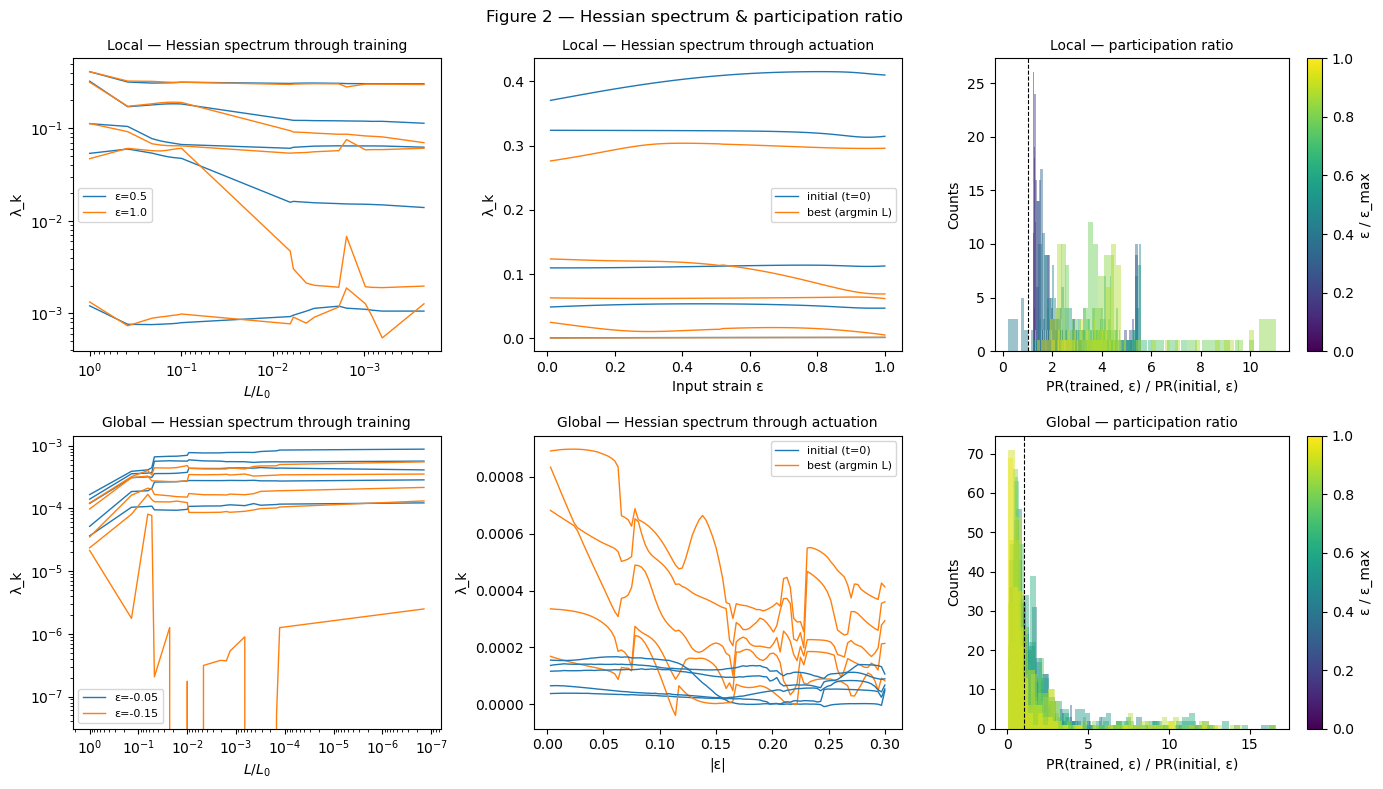

Figure 2 saved.


In [ ]:
# ── Load loss trajectories for relative-error x-axis ────────────────────────
_, loss_g_plt = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
L_0_g_plt   = max(float(loss_g_plt[0]), 1e-300)

def _rel_err_x(t_indices, loss, L0):
    """Relative error at each selected step: (L[t] - L_min) / L_min."""
    return (loss[t_indices.astype(int)]) / L0

# ── Figure 2: plot ─────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
fig2.suptitle('Figure 2 — Hessian spectrum & participation ratio', fontsize=12)

from matplotlib.lines import Line2D
viridis = plt.get_cmap('viridis')
C_ES1, C_ES2 = 'tab:blue', 'tab:orange'

# ── Row 0: LOCAL ──────────────────────────────────────────────────────────────

# Col 0 (local): eigenvalue lines vs normalized training step
ax = axes2[0, 0]
if l_train is not None:
    t_idx_l   = l_train['t_indices'].astype(int)
    L_0_l   = max(float(local_traj_loss[0]), 1e-300)
    rel_err_l = _rel_err_x(t_idx_l, local_traj_loss, L_0_l)
    eigs1   = l_train['eigs_es1']     # (n_t, M)
    eigs2   = l_train['eigs_es2']
    M = min(5, eigs1.shape[1])
    for k in range(M):
        y1 = eigs1[:, k]; y2 = eigs2[:, k]
        ax.plot(rel_err_l, y1, c=C_ES1, lw=1)
        ax.plot(rel_err_l, y2, c=C_ES2, lw=1)
    ax.legend([Line2D([0],[0],color=C_ES1,lw=1),
               Line2D([0],[0],color=C_ES2,lw=1)],
              [f'ε={LOCAL_ES_1}', f'ε={LOCAL_ES_2}'], fontsize=8)
    ax.set_yscale('log'); ax.set_xscale('log')
    ax.invert_xaxis() 
    ax.set_xlabel('$L/L_{0}$', fontsize=10)
    ax.set_ylabel('λ_k', fontsize=10)
    ax.set_title('Local — Hessian spectrum through training', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No stiffness trajectory\n(re-train to generate)',
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')
    ax.set_title('Local — Hessian spectrum through training', fontsize=10)

# Col 1 (local): eigenvalue lines vs actuation strain, two timesteps
ax = axes2[0, 1]
if l_act is not None:
    strain_range_l = l_act['es_range']     # (n_s,)
    eigs_t1_l = l_act['eigs_t1']     # (n_s, M)
    eigs_t2_l = l_act['eigs_t2']
    t_norm_1_l = float(l_act['t_1'])
    t_norm_2_l = float(l_act['t_2'])
    M = min(5, eigs_t1_l.shape[1])
    for k in range(M):
        ax.plot(strain_range_l, eigs_t1_l[:, k], c=C_ES1, lw=1)
        ax.plot(strain_range_l, eigs_t2_l[:, k], c=C_ES2, lw=1, ls='-')
    ax.legend([Line2D([0],[0],color=C_ES1,lw=1),
               Line2D([0],[0],color=C_ES2,lw=1,ls='-')],
              ['initial (t=0)', 'best (argmin L)'], fontsize=8)
    # ax.set_yscale('log')
    ax.set_xlabel('Input strain ε', fontsize=10)
    ax.set_ylabel('λ_k', fontsize=10)
    ax.set_title('Local — Hessian spectrum through actuation', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No stiffness trajectory\n(re-train to generate)',
            ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')
    ax.set_title('Local — Hessian spectrum through actuation', fontsize=10)

# Col 2 (local): PR histograms per epsilon, colored by epsilon (viridis)
ax = axes2[0, 2]
if pr_local_eps_all:
    bins = np.linspace(0, 1, N_EPS_BINS + 1)
    norm_eps = Normalize(vmin=0, vmax=1)
    for b_lo, b_hi in zip(bins[:-1], bins[1:]):
        color = viridis(norm_eps((b_lo + b_hi) / 2))
        ratios_in_bin = []
        for eps_arr, ratio_arr in zip(pr_local_eps_all, pr_local_ratio_all):
            mask = (eps_arr >= b_lo) & (eps_arr < b_hi)
            vals = ratio_arr[mask]
            vals = vals[np.isfinite(vals)]
            ratios_in_bin.extend(vals.tolist())
        if ratios_in_bin:
            ax.hist(ratios_in_bin, bins=40, alpha=0.45, color=color, density=False)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_eps)
    sm.set_array([])
    fig2.colorbar(sm, ax=ax, label='ε / ε_max')
    ax.axvline(1.0, c='k', lw=0.8, ls='--')
    ax.set_xlabel('PR(trained, ε) / PR(initial, ε)', fontsize=10)
    ax.set_ylabel('Counts', fontsize=10)
ax.set_title('Local — participation ratio', fontsize=10)

# ── Row 1: GLOBAL ─────────────────────────────────────────────────────────────

# Col 0 (global): eigenvalue lines vs normalized training step
ax = axes2[1, 0]
t_idx     = g_train['t_indices'].astype(int)
rel_err_g = _rel_err_x(t_idx, loss_g_plt, L_0_g_plt)
eigs1_g   = g_train['eigs_es1']   # (n_t, M)
eigs2_g   = g_train['eigs_es2']
M_g = min(5, eigs1_g.shape[1])
for k in range(M_g):
    y1 = eigs1_g[:, k]; y2 = eigs2_g[:, k]
    ax.plot(rel_err_g, y1, c=C_ES1, lw=1)
    ax.plot(rel_err_g, y2, c=C_ES2, lw=1)
ax.legend([Line2D([0],[0],color=C_ES1,lw=1),
           Line2D([0],[0],color=C_ES2,lw=1)],
          [f'ε={ES_1}', f'ε={ES_2}'], fontsize=8)
ax.invert_xaxis() 
ax.set_yscale('log'); 
ax.set_xscale('log')
ax.set_xlabel('$L/L_0$', fontsize=10)
ax.set_ylabel('λ_k', fontsize=10)
ax.set_title('Global — Hessian spectrum through training', fontsize=10)

# Col 1 (global): eigenvalue lines vs actuation strain, two timesteps
ax = axes2[1, 1]
comp_range_g = g_act['comp_range']
eigs_t1_g    = g_act['eigs_t1']     # (n_cs, M)
eigs_t2_g    = g_act['eigs_t2']
t_1_g        = int(g_act['t_1'])
t_2_g        = int(g_act['t_2'])
t_norm_1_g   = t_1_g / max(float(g_act['T_total']) - 1, 1)
t_norm_2_g   = t_2_g / max(float(g_act['T_total']) - 1, 1)
M_g = min(5, eigs_t1_g.shape[1])
for k in range(M_g):
    y1 = eigs_t1_g[:, k]; y2 = eigs_t2_g[:, k]
    ax.plot(comp_range_g, y1, c=C_ES1, lw=1)
    ax.plot(comp_range_g, y2, c=C_ES2, lw=1, ls='-')
ax.legend([Line2D([0],[0],color=C_ES1,lw=1),
           Line2D([0],[0],color=C_ES2,lw=1,ls='-')],
          ['initial (t=0)', 'best (argmin L)'], fontsize=8)
# ax.set_yscale('log')
ax.set_xlabel('|ε|', fontsize=10)
ax.set_ylabel('λ_k', fontsize=10)
ax.set_title('Global — Hessian spectrum through actuation', fontsize=10)

# Col 2 (global): PR histograms per epsilon, colored by epsilon (viridis)
ax = axes2[1, 2]
if pr_global_eps_all:
    bins = np.linspace(0, 1, N_EPS_BINS + 1)
    norm_eps = Normalize(vmin=0, vmax=1)
    for b_lo, b_hi in zip(bins[:-1], bins[1:]):
        color = viridis(norm_eps((b_lo + b_hi) / 2))
        ratios_in_bin = []
        for eps_arr, ratio_arr in zip(pr_global_eps_all, pr_global_ratio_all):
            mask = (eps_arr >= b_lo) & (eps_arr < b_hi)
            vals = ratio_arr[mask]
            vals = vals[np.isfinite(vals)]
            ratios_in_bin.extend(vals.tolist())
        if ratios_in_bin:
            ax.hist(ratios_in_bin, bins=40, alpha=0.45, color=color, density=False)
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_eps)
    sm.set_array([])
    fig2.colorbar(sm, ax=ax, label='ε / ε_max')
    ax.axvline(1.0, c='k', lw=0.8, ls='--')
    ax.set_xlabel('PR(trained, ε) / PR(initial, ε)', fontsize=10)
    ax.set_ylabel('Counts', fontsize=10)
ax.set_title('Global — participation ratio', fontsize=10)

fig2.tight_layout()
plt.show()
fig2.savefig(FIGURE_OUT_DIR / 'fig2_hessian_spectrum_pr.pdf', bbox_inches='tight', dpi=150)
print('Figure 2 saved.')

## Figure 3 — Hessian Spectrum · PR vs Training Step

Same cols 0 & 1 as Figure 2 (lowest 10 eigenvalue lines).  
**Col 2 (main):** PR(t, ε=ε₁), PR(t, ε=ε₂), PR(t, ε≈0) vs training step t for the representative task.  
**Col 2 (alt):** semi-transparent lines of PR(trained, ε) and PR(initial, ε) vs ε.

In [ ]:
# ── Figure 3: compute PR vs training step (cached) ───────────────────────────
print('=== Figure 3: PR vs training step ===')

def _frame_idx(target_eps_abs, max_eps_abs, n_steps):
    """Frame index in PR array (length n_steps) for a target |compression|."""
    if max_eps_abs < 1e-12:
        return 0
    return min(int(round(target_eps_abs / max_eps_abs * n_steps)), n_steps - 1)

# ── GLOBAL: PR(t, ES_1), PR(t, ES_2), PR(t, ε≈0) vs t ───────────────────────
key_g_pr_t = f'june_fig3_pr_vs_t_global_t{GLOBAL_TASK_ID:02d}_r{GLOBAL_REAL_ID:02d}_v2'
k_traj_g_3, loss_g_3 = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
if cache_exists(key_g_pr_t):
    g_pr_t = load_cache(key_g_pr_t)
    print(f'  Global PR-vs-t: loaded from cache ({len(g_pr_t["t_norm"])} points)')
else:
    k_traj_g = k_traj_g_3; loss_g = loss_g_3
    T_g        = len(k_traj_g)
    t_indices  = select_loss_threshold_steps(loss_g, N_THRESH_STEPS, THRESH_EPS_MIN)
    n_t        = len(t_indices)
    max_cs     = float(np.max(np.abs([ES_1, ES_2])))
    n_pr_steps = N_STEPS_FIG2
    pr_es1_g   = np.full(n_t, np.nan)
    pr_es2_g   = np.full(n_t, np.nan)
    pr_es0_g   = np.full(n_t, np.nan)
    fi1 = _frame_idx(abs(ES_1), max_cs, n_pr_steps)
    fi2 = _frame_idx(abs(ES_2), max_cs, n_pr_steps)
    fi0 = 0
    print(f'  Global PR-vs-t: computing {n_t} timesteps (max_cs={max_cs:.3f})...')
    for i, t_idx in enumerate(t_indices):
        k_t = k_traj_g[t_idx]
        net = copy.deepcopy(global_rep_net)
        net.stiffnesses = k_t
        try:
            traj = compute_global_traj(net, -max_cs, global_rep_bnd, n_steps=n_pr_steps)
            _, ovl = compute_analysis(traj, k_t, global_rep_net.rest_lengths,
                                      global_rep_net.edges, global_rep_fdofs)
            pr = participation_ratio(ovl)   # (n_pr_steps,)
            if fi0 < len(pr): pr_es0_g[i] = pr[fi0]
            if fi1 < len(pr): pr_es1_g[i] = pr[fi1]
            if fi2 < len(pr): pr_es2_g[i] = pr[fi2]
        except Exception as e:
            pass
        if (i + 1) % 10 == 0:
            print(f'    {i+1}/{n_t}', flush=True)
    t_norm_g2 = t_indices / max(T_g - 1, 1)
    save_cache(key_g_pr_t, t_norm=t_norm_g2, t_indices=t_indices,
               pr_es1=pr_es1_g, pr_es2=pr_es2_g, pr_es0=pr_es0_g,
               ES_1=np.array(ES_1), ES_2=np.array(ES_2))
    g_pr_t = load_cache(key_g_pr_t)
    print('  Global PR-vs-t: done and cached.')

# ── GLOBAL: PR(trained, ε) and PR(initial, ε) vs ε ───────────────────────────
key_g_pr_eps = f'june_fig3_pr_vs_eps_global_t{GLOBAL_TASK_ID:02d}_r{GLOBAL_REAL_ID:02d}'
if cache_exists(key_g_pr_eps):
    g_pr_eps = load_cache(key_g_pr_eps)
    print('  Global PR-vs-eps: loaded from cache')
else:
    k_traj_g, loss_g = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
    k_tr  = k_traj_g[np.argmin(loss_g)]
    k_in  = k_traj_g[0]
    max_cs = float(np.max(np.abs(global_rep_cfg['compression_strains'])))
    n_steps_eps = N_STEPS_FIG2
    eps_range = np.linspace(0, max_cs, n_steps_eps + 1)[1:]
    pr_trained_g = np.full(n_steps_eps, np.nan)
    pr_initial_g = np.full(n_steps_eps, np.nan)
    for i, cs in tqdm(enumerate(eps_range), total=n_steps_eps):
        for k_use, pr_arr in [(k_tr, pr_trained_g), (k_in, pr_initial_g)]:
            net = copy.deepcopy(global_rep_net)
            net.stiffnesses = k_use
            traj = compute_global_traj(net, -cs, global_rep_bnd, n_steps=max(5, n_steps_eps//4))
            _, ovl = compute_analysis(traj, k_use, global_rep_net.rest_lengths,
                                        global_rep_net.edges, global_rep_fdofs)
            pr = participation_ratio(ovl)
            if len(pr): pr_arr[i] = pr[-1]
    save_cache(key_g_pr_eps, eps_range=eps_range,
               pr_trained=pr_trained_g, pr_initial=pr_initial_g)
    g_pr_eps = load_cache(key_g_pr_eps)
    print('  Global PR-vs-eps: done and cached.')

# ── LOCAL ────────────────────────────────────────────────────────────────────────
l_pr_t = l_pr_eps = None
local_rep_fdofs = local_rep['free_dofs']

key_l_pr_t = f'june_fig3_pr_vs_t_local_t{LOCAL_TASK_ID}_r{LOCAL_REAL_ID}_v2'
if cache_exists(key_l_pr_t):
    l_pr_t = load_cache(key_l_pr_t)
    print(f'  Local PR-vs-t: loaded from cache')
else:
    T_l      = len(local_traj_k)
    t_indices_l = select_loss_threshold_steps(local_traj_loss, N_THRESH_STEPS, THRESH_EPS_MIN)
    n_t_l    = len(t_indices_l)
    max_ls   = max(LOCAL_ES_1, LOCAL_ES_2)
    n_pr_steps_l = N_STEPS_FIG2
    pr_es1_l = np.full(n_t_l, np.nan)
    pr_es2_l = np.full(n_t_l, np.nan)
    pr_es0_l = np.full(n_t_l, np.nan)
    fi1_l = _frame_idx(LOCAL_ES_1, max_ls, n_pr_steps_l)
    fi2_l = _frame_idx(LOCAL_ES_2, max_ls, n_pr_steps_l)
    print(f'  Local PR-vs-t: computing {n_t_l} checkpoints...')
    for i, t_idx in tqdm(enumerate(t_indices_l), total=n_t_l):
        k_t = local_traj_k[t_idx]
        nd  = {**local_rep, 'stiffnesses': k_t}
        traj = compute_local_traj(nd, max_strain=max_ls, n_steps=n_pr_steps_l)
        _, ovl = compute_analysis(traj, k_t, local_rep['eq_lengths'],
                                    local_rep['edges'], local_rep_fdofs)
        pr = participation_ratio(ovl)
        if 0     < len(pr): pr_es0_l[i] = pr[0]
        if fi1_l < len(pr): pr_es1_l[i] = pr[fi1_l]
        if fi2_l < len(pr): pr_es2_l[i] = pr[fi2_l]
    t_norm_l2 = local_traj_steps[t_indices_l] / max(local_traj_steps[-1], 1)
    save_cache(key_l_pr_t, t_norm=t_norm_l2, t_indices=t_indices_l,
               pr_es1=pr_es1_l, pr_es2=pr_es2_l, pr_es0=pr_es0_l,
               LOCAL_ES_1=np.array(LOCAL_ES_1), LOCAL_ES_2=np.array(LOCAL_ES_2))
    l_pr_t = load_cache(key_l_pr_t)
    print('  Local PR-vs-t: done and cached.')


=== Figure 3: PR vs training step ===
    threshold steps: 19 (target 50, new-record lows=19, t_star=174)
  Global PR-vs-t: computing 19 timesteps (max_cs=0.150)...
    10/19
  Global PR-vs-t: done and cached.
  Global PR-vs-eps: done and cached.
    threshold steps: 18 (target 50, new-record lows=20, t_star=29)
  Local PR-vs-t: computing 18 checkpoints...


 50%|█████     | 9/18 [02:59<02:56, 19.56s/it]

    10/18


100%|██████████| 18/18 [05:57<00:00, 19.85s/it]


  Local PR-vs-t: done and cached.


KeyboardInterrupt: 

In [ ]:

key_l_pr_eps = f'june_fig3_pr_vs_eps_local_t{LOCAL_TASK_ID}_r{LOCAL_REAL_ID}'
if cache_exists(key_l_pr_eps):
    l_pr_eps = load_cache(key_l_pr_eps)
    print('  Local PR-vs-eps: loaded from cache')
else:
    if local_traj_loss is not None:
        best_l3 = int(np.argmin(local_traj_loss))
        k_tr_l, k_in_l = local_traj_k[best_l3], local_traj_k[0]
    else:
        k_tr_l = local_rep['stiffnesses']   # fallback: final stiffnesses file
        k_in_l = local_traj_k[0]
    n_steps_eps_l = N_STEPS_FIG2
    eps_range_l = np.linspace(0, LOCAL_MAX_STRAIN, n_steps_eps_l + 1)[1:]
    pr_trained_l = np.full(n_steps_eps_l, np.nan)
    pr_initial_l = np.full(n_steps_eps_l, np.nan)
    
    for k_use, pr_arr in [(k_tr_l, pr_trained_l), (k_in_l, pr_initial_l)]:
        nd = {**local_rep, 'stiffnesses': k_use}
        traj = compute_local_traj(nd, max_strain=LOCAL_MAX_STRAIN,
                                          n_steps=max(5, n_steps_eps_l // 4))
        _, ovl = compute_analysis(traj, k_use, local_rep['eq_lengths'],
                                          local_rep['edges'], local_rep['free_dofs'])
        pr = participation_ratio(ovl)
        pr_arr = pr
        
    save_cache(key_l_pr_eps, eps_range=eps_range_l,
               pr_trained=pr_trained_l, pr_initial=pr_initial_l)
    l_pr_eps = load_cache(key_l_pr_eps)
    print('  Local PR-vs-eps: done and cached.')

print('\nFigure 3 data ready.')


  Local PR-vs-eps: done and cached.

Figure 3 data ready.


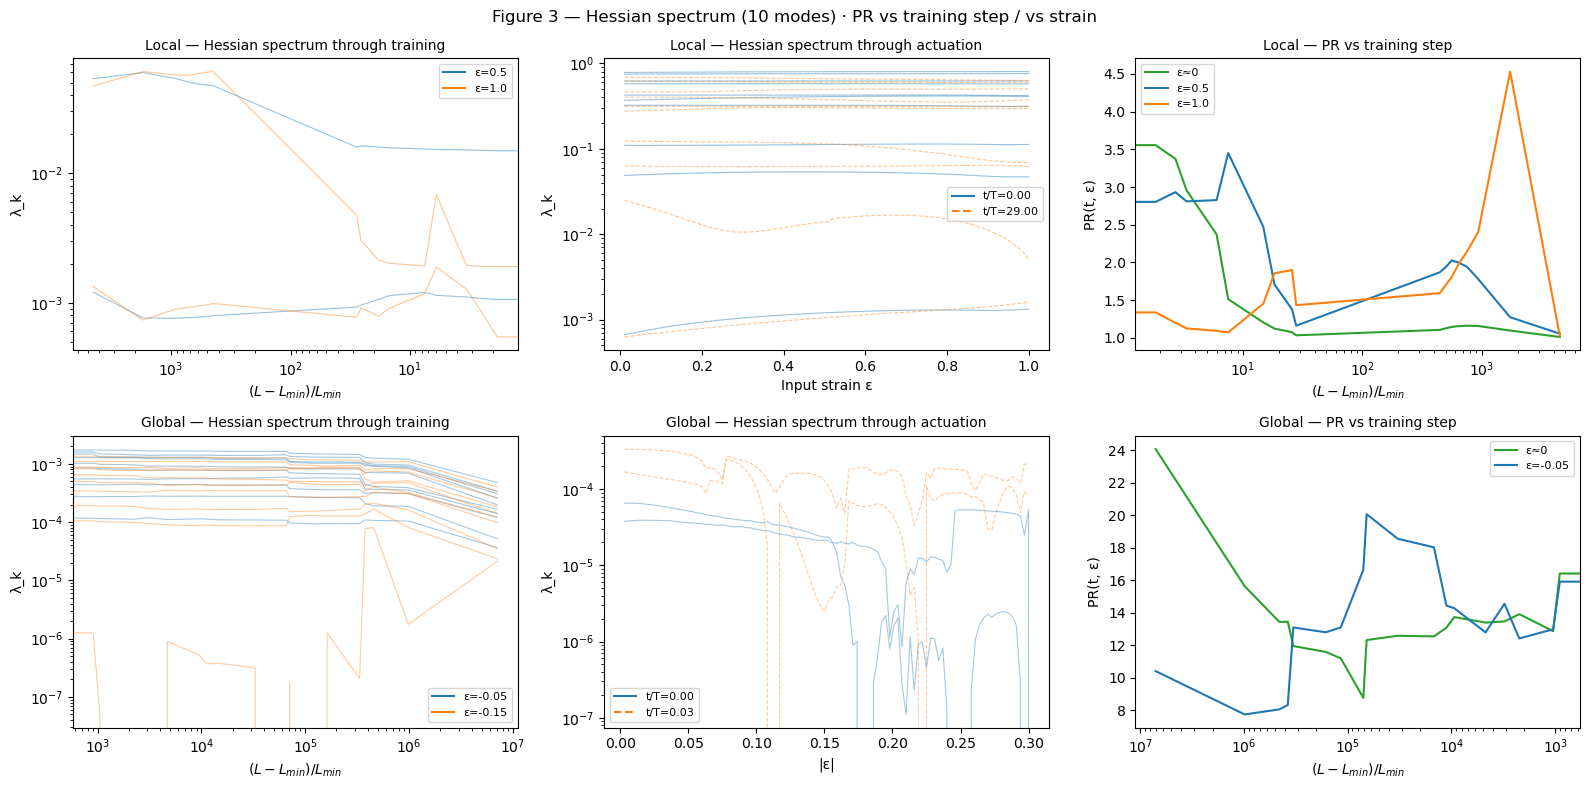

Figure 3 saved.


In [ ]:
# ── Load loss trajectories for relative-error x-axis ────────────────────────
_, loss_g_plt3 = load_global_stiffness_trajectory(GLOBAL_TASK_ID, GLOBAL_REAL_ID)
L_min_g_plt3   = max(float(loss_g_plt3.min()), 1e-300)

def _rel_err_x3(t_indices, loss, L_min):
    return (loss[t_indices.astype(int)] - L_min) / L_min

# ── Figure 3: plot ────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 8))
fig3.suptitle('Figure 3 — Hessian spectrum (10 modes) · PR vs training step / vs strain',
              fontsize=12)

from matplotlib.lines import Line2D
C_ES1, C_ES2, C_ES0 = 'tab:blue', 'tab:orange', 'tab:green'
C_TR, C_IN = 'tab:red', 'tab:gray'

# ── Row 0: LOCAL ──────────────────────────────────────────────────────────────

# Col 0 (local): lowest 10 eigenvalue lines vs training step  [reuse l_train]
ax = axes3[0, 0]
if l_train is not None:
    t_idx_l3  = l_train['t_indices'].astype(int)
    L_min_l3  = max(float(local_traj_loss.min()), 1e-300)
    re_l3     = _rel_err_x3(t_idx_l3, local_traj_loss, L_min_l3)
    eigs1 = np.sort(l_train['eigs_es1'], axis=1)
    eigs2 = np.sort(l_train['eigs_es2'], axis=1)
    M = min(10, eigs1.shape[1])
    for k in range(M):
        m1 = np.isfinite(eigs1[:, k]); m2 = np.isfinite(eigs2[:, k])
        if m1.any(): ax.plot(re_l3[m1], eigs1[m1, k], c=C_ES1, alpha=0.45, lw=0.8)
        if m2.any(): ax.plot(re_l3[m2], eigs2[m2, k], c=C_ES2, alpha=0.45, lw=0.8)
    ax.legend([Line2D([0],[0],color=C_ES1,lw=1.5),
               Line2D([0],[0],color=C_ES2,lw=1.5)],
              [f'ε={LOCAL_ES_1}', f'ε={LOCAL_ES_2}'], fontsize=8)
    ax.set_yscale('log'); ax.set_xscale('log'); ax.invert_xaxis()
    ax.set_xlabel('$(L - L_{min})/L_{min}$', fontsize=10); ax.set_ylabel('λ_k', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No stiffness trajectory', ha='center', va='center',
            transform=ax.transAxes, color='gray')
ax.set_title('Local — Hessian spectrum through training', fontsize=10)

# Col 1 (local): lowest 10 eigenvalue lines vs actuation  [reuse l_act]
ax = axes3[0, 1]
if l_act is not None:
    sr = l_act['es_range']; e1 = l_act['eigs_t1']; e2 = l_act['eigs_t2']
    tn1 = float(l_act['t_1']); tn2 = float(l_act['t_2'])
    M = min(10, e1.shape[1])
    for k in range(M):
        ax.plot(sr, e1[:, k], c=C_ES1, alpha=0.45, lw=0.8)
        ax.plot(sr, e2[:, k], c=C_ES2, alpha=0.45, lw=0.8, ls='--')
    ax.legend([Line2D([0],[0],color=C_ES1,lw=1.5),
               Line2D([0],[0],color=C_ES2,lw=1.5,ls='--')],
              [f't/T={tn1:.2f}', f't/T={tn2:.2f}'], fontsize=8)
    ax.set_yscale('log'); ax.set_xlabel('Input strain ε', fontsize=10); ax.set_ylabel('λ_k', fontsize=10)
else:
    ax.text(0.5, 0.5, 'No stiffness trajectory', ha='center', va='center',
            transform=ax.transAxes, color='gray')
ax.set_title('Local — Hessian spectrum through actuation', fontsize=10)

# Col 2 (local): PR vs training step (main) + PR vs eps (alt, inset or twin)
ax = axes3[0, 2]
if l_pr_t is not None:
    t_idx_lpr = l_pr_t['t_indices'].astype(int) if 't_indices' in l_pr_t else None
    if t_idx_lpr is not None and local_traj_loss is not None:
        L_min_lpr = max(float(local_traj_loss.min()), 1e-300)
        x_lpr = _rel_err_x3(t_idx_lpr, local_traj_loss, L_min_lpr)
    else:
        x_lpr = l_pr_t['t_norm']
    p0 = l_pr_t['pr_es0']; p1 = l_pr_t['pr_es1']; p2 = l_pr_t['pr_es2']
    m0 = np.isfinite(p0); m1 = np.isfinite(p1); m2 = np.isfinite(p2)
    if m0.any(): ax.plot(x_lpr[m0], p0[m0], c=C_ES0, lw=1.5, label='ε≈0')
    if m1.any(): ax.plot(x_lpr[m1], p1[m1], c=C_ES1, lw=1.5, label=f'ε={LOCAL_ES_1}')
    if m2.any(): ax.plot(x_lpr[m2], p2[m2], c=C_ES2, lw=1.5, label=f'ε={LOCAL_ES_2}')
    ax.set_xscale('log')
    ax.set_xlabel('$(L - L_{min})/L_{min}$', fontsize=10)
    ax.set_ylabel('PR(t, ε)', fontsize=10)
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No stiffness trajectory', ha='center', va='center',
            transform=ax.transAxes, color='gray')
ax.set_title('Local — PR vs training step', fontsize=10)

# ── Row 1: GLOBAL ─────────────────────────────────────────────────────────────

# Col 0 (global): lowest 10 eigenvalue lines vs training step  [reuse g_train]
ax = axes3[1, 0]
t_idx_g3 = g_train['t_indices'].astype(int)
re_g3    = _rel_err_x3(t_idx_g3, loss_g_plt3, L_min_g_plt3)
e1g = np.sort(g_train['eigs_es1'], axis=1)
e2g = np.sort(g_train['eigs_es2'], axis=1)
Mg = min(10, e1g.shape[1])
for k in range(Mg):
    y1 = e1g[:, k]; y2 = e2g[:, k]
    m1 = np.isfinite(y1); m2 = np.isfinite(y2)
    if m1.any(): ax.plot(re_g3[m1], y1[m1], c=C_ES1, alpha=0.4, lw=0.8)
    if m2.any(): ax.plot(re_g3[m2], y2[m2], c=C_ES2, alpha=0.4, lw=0.8)
ax.legend([Line2D([0],[0],color=C_ES1,lw=1.5),
           Line2D([0],[0],color=C_ES2,lw=1.5)],
          [f'ε={ES_1}', f'ε={ES_2}'], fontsize=8)
ax.set_yscale('log'); ax.set_xscale('log');
ax.set_xlabel('$(L - L_{min})/L_{min}$', fontsize=10); ax.set_ylabel('λ_k', fontsize=10)
ax.set_title('Global — Hessian spectrum through training', fontsize=10)

# Col 1 (global): lowest 10 eigenvalue lines vs actuation  [reuse g_act]
ax = axes3[1, 1]
crg = g_act['comp_range']; 
et1 = np.sort(g_act['eigs_t1'], axis=1)  # sort eigenvalues at each strain
et2 = np.sort(g_act['eigs_t2'], axis=1)
tn1g = int(g_act['t_1']) / max(float(g_act['T_total']) - 1, 1)
tn2g = int(g_act['t_2']) / max(float(g_act['T_total']) - 1, 1)
Mg = min(2, et1.shape[1])
for k in range(Mg):
    y1 = et1[:, k]; 
    y2 = et2[:, k]
    ax.plot(crg, y1, c=C_ES1, alpha=0.4, lw=0.8)
    ax.plot(crg, y2, c=C_ES2, alpha=0.4, lw=0.8, ls='--')
ax.legend([Line2D([0],[0],color=C_ES1,lw=1.5),
           Line2D([0],[0],color=C_ES2,lw=1.5,ls='--')],
          [f't/T={tn1g:.2f}', f't/T={tn2g:.2f}'], fontsize=8)
ax.set_yscale('log'); ax.set_xlabel('|ε|', fontsize=10); ax.set_ylabel('λ_k', fontsize=10)
ax.set_title('Global — Hessian spectrum through actuation', fontsize=10)

# Col 2 (global): PR vs training step (main) + PR vs eps (alt)
ax = axes3[1, 2]
t_idx_gpr = g_pr_t['t_indices'].astype(int) if 't_indices' in g_pr_t else None
if t_idx_gpr is not None:
    x_gpr = _rel_err_x3(t_idx_gpr, loss_g_plt3, L_min_g_plt3)
else:
    x_gpr = g_pr_t['t_norm']
p0 = g_pr_t['pr_es0']; p1 = g_pr_t['pr_es1']; p2 = g_pr_t['pr_es2']
m0 = np.isfinite(p0); m1 = np.isfinite(p1); m2 = np.isfinite(p2)
if m0.any(): ax.plot(x_gpr[m0], p0[m0], c=C_ES0, lw=1.5, label='ε≈0')
if m1.any(): ax.plot(x_gpr[m1], p1[m1], c=C_ES1, lw=1.5, label=f'ε={ES_1}')
if m2.any(): ax.plot(x_gpr[m2], p2[m2], c=C_ES2, lw=1.5, label=f'ε={ES_2}')
ax.set_xscale('log'); ax.invert_xaxis()
ax.set_xlabel('$(L - L_{min})/L_{min}$', fontsize=10)
ax.set_ylabel('PR(t, ε)', fontsize=10)
ax.legend(fontsize=8)
ax.set_title('Global — PR vs training step', fontsize=10)

fig3.tight_layout()
plt.show()
fig3.savefig(FIGURE_OUT_DIR / 'fig3_hessian_pr_training.pdf', bbox_inches='tight', dpi=150)
print('Figure 3 saved.')

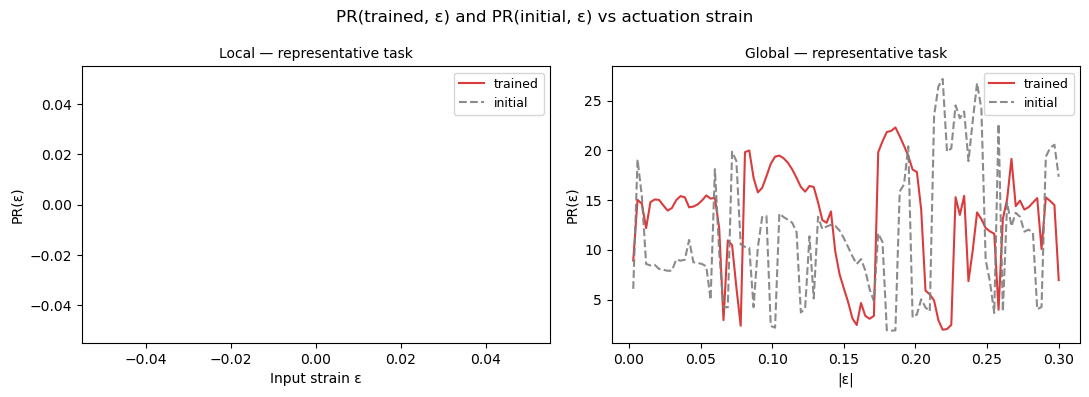

Figure 3b saved.


In [ ]:

# ── Figure 3b: PR(trained, ε) and PR(initial, ε) vs ε ────────────────────────
fig3b, axes3b = plt.subplots(1, 2, figsize=(11, 4))
fig3b.suptitle('PR(trained, ε) and PR(initial, ε) vs actuation strain', fontsize=12)

ax = axes3b[0]
if l_pr_eps is not None:
    er = l_pr_eps['eps_range']
    ax.plot(er, l_pr_eps['pr_trained'], c=C_TR, alpha=0.9, lw=1.5, label='trained')
    ax.plot(er, l_pr_eps['pr_initial'], c=C_IN, alpha=0.9, lw=1.5, label='initial', ls='--')
    ax.set_xlabel('Input strain ε', fontsize=10)
    ax.set_ylabel('PR(ε)', fontsize=10)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'No stiffness trajectory', ha='center', va='center',
            transform=ax.transAxes, color='gray')
ax.set_title('Local — representative task', fontsize=10)

ax = axes3b[1]
er = g_pr_eps['eps_range']
ax.plot(er, g_pr_eps['pr_trained'], c=C_TR, alpha=0.9, lw=1.5, label='trained')
ax.plot(er, g_pr_eps['pr_initial'], c=C_IN, alpha=0.9, lw=1.5, label='initial', ls='--')
ax.set_xlabel('|ε|', fontsize=10)
ax.set_ylabel('PR(ε)', fontsize=10)
ax.legend(fontsize=9)
ax.set_title('Global — representative task', fontsize=10)

fig3b.tight_layout()
plt.show()
fig3b.savefig(FIGURE_OUT_DIR / 'fig3b_pr_vs_eps.pdf', bbox_inches='tight', dpi=150)
print('Figure 3b saved.')


In [ ]:
from tqdm import tqdm 
# ── λ₀(trained)/λ₀(initial) histograms across all targeted tasks ──────────────
# Hessian evaluated at rest (ε=0) AND at each task's subtask compression(s).
print('=== λ₀ ratio histograms ===')

def lambda0_at_rest_global(task_id, real_id):
    """Return (lambda0_trained, lambda0_initial) for a global targeted task at ε=0."""
    key = f'june_lambda0_global_t{task_id:02d}_r{real_id:02d}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        return float(d['lambda0_trained']), float(d['lambda0_initial'])
    net, bnd, _ = load_global_network(task_id, real_id, data_dir=TARGETED_DIR)
    N_g  = len(net.positions)
    fdofs_g = free_dofs_global(N_g, bnd['top'], bnd['bottom'])
    k_traj_g, loss_g = load_global_stiffness_trajectory(task_id, real_id)
    k_tr = k_traj_g[np.argmin(loss_g)]
    k_in = k_traj_g[0]
    vals_tr, _ = hessian_modes(net.positions, k_tr, net.rest_lengths, net.edges, None)#, fdofs_g)
    vals_in, _ = hessian_modes(net.positions, k_in, net.rest_lengths, net.edges, None)#, fdofs_g)
    l0_tr = float(vals_tr[0]); l0_in = float(vals_in[0])
    save_cache(key, lambda0_trained=np.array(l0_tr), lambda0_initial=np.array(l0_in))
    return l0_tr, l0_in

def lambda0_at_rest_local(task_id, real_id):
    """Return (lambda0_trained, lambda0_initial) for a local targeted task at ε=0."""
    key = f'june_lambda0_local_t{task_id}_r{real_id}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        return float(d['lambda0_trained']), float(d['lambda0_initial'])
    nd = load_local_targeted(task_id, real_id)
    if nd is None:
        return np.nan, np.nan
    fdofs = nd['free_dofs']
    traj_k_l, _, traj_loss_l = load_local_stiffness_trajectory(task_id, real_id)
    best_l = int(np.argmin(traj_loss_l))
    k_tr, k_in = traj_k_l[best_l], traj_k_l[0]
    vals_tr, _ = hessian_modes(nd['nodes'], k_tr, nd['eq_lengths'], nd['edges'], None)#, fdofs)
    vals_in, _ = hessian_modes(nd['nodes'], k_in, nd['eq_lengths'], nd['edges'], None)#, fdofs)
    l0_tr = float(vals_tr[0]); l0_in = float(vals_in[0])
    save_cache(key, lambda0_trained=np.array(l0_tr), lambda0_initial=np.array(l0_in))
    return l0_tr, l0_in

def lambda0_at_compression_global(task_id, real_id, compression):
    """λ₀(trained) and λ₀(initial) at equilibrium under `compression` (negative)."""
    cs_tag = f'{abs(compression):.3f}'.replace('.', 'p')
    key = f'june_lambda0cs_global_t{task_id:02d}_r{real_id:02d}_cs{cs_tag}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        return float(d['lambda0_trained']), float(d['lambda0_initial'])
    net, bnd, _ = load_global_network(task_id, real_id, data_dir=TARGETED_DIR)
    fdofs_g = free_dofs_global(len(net.positions), bnd['top'], bnd['bottom'])
    k_traj_g, loss_g = load_global_stiffness_trajectory(task_id, real_id)
    k_tr = k_traj_g[np.argmin(loss_g)];  k_in = k_traj_g[0]
    vals_tr = hessian_eigs_global(k_tr, net, float(compression), bnd, fdofs_g)
    vals_in = hessian_eigs_global(k_in, net, float(compression), bnd, fdofs_g)
    l0_tr = float(np.abs(vals_tr[0]));  l0_in = float(np.abs(vals_in[0]))
    save_cache(key, lambda0_trained=np.array(l0_tr), lambda0_initial=np.array(l0_in))
    return l0_tr, l0_in

def lambda0_at_compression_local(task_id, real_id, strain):
    """λ₀(trained) and λ₀(initial) at equilibrium under `strain` for local tasks."""
    s_tag = f'{strain:.3f}'.replace('.', 'p')
    key = f'june_lambda0cs_local_t{task_id}_r{real_id}_s{s_tag}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        return float(d['lambda0_trained']), float(d['lambda0_initial'])
    nd = load_local_targeted(task_id, real_id)
    if nd is None:
        return np.nan, np.nan
    fdofs = nd['free_dofs']
    traj_k_l, _, traj_loss_l = load_local_stiffness_trajectory(task_id, real_id)
    best_l = int(np.argmin(traj_loss_l))
    k_tr, k_in = traj_k_l[best_l], traj_k_l[0]
    vals_tr = hessian_eigs_local(k_tr, nd, strain, fdofs)
    vals_in = hessian_eigs_local(k_in, nd, strain, fdofs)
    l0_tr = float(np.abs(vals_tr[0]));  l0_in = float(np.abs(vals_in[0]))
    save_cache(key, lambda0_trained=np.array(l0_tr), lambda0_initial=np.array(l0_in))
    return l0_tr, l0_in

# ── Collect ratios at ε=0 AND each task's subtask compressions ────────────────
# Ensemble: all available realizations per task.
global_ratios_by_cs = {}   # {float_cs: [ratio, ...]}
local_ratios_by_cs  = {}

def _global_reals(task_id):
    return sorted((TARGETED_DIR / f'task_{task_id:02d}').glob('realization_*'))

def _local_reals(task_id):
    return sorted((ALLOSTERIC_TGT_DIR / f'task_{task_id}').glob('realization_*'))

# ε = 0 (rest)
print('Now subtasks at rest - global')
for task_id in tqdm(PR_GLOBAL_TASKS):
    for real_dir in _global_reals(task_id):
        real_id = int(real_dir.name.split('_')[1])
        l0_tr, l0_in = lambda0_at_rest_global(task_id, real_id)
        if np.isfinite(l0_tr) and l0_in > 0:
            global_ratios_by_cs.setdefault(0.0, []).append(l0_tr / l0_in)

print('Now subtasks at rest - local')
for task_id in tqdm(PR_LOCAL_TASKS):
    for real_dir in _local_reals(task_id):
        real_id = int(real_dir.name.split('_')[1])
        try:
            l0_tr, l0_in = lambda0_at_rest_local(task_id, real_id)
        except Exception as e:
            print(f"Error occurred while processing local task {task_id}, realization {real_id}: {e}")
            continue
        if np.isfinite(l0_tr) and l0_in > 0:
            local_ratios_by_cs.setdefault(0.0, []).append(l0_tr / l0_in)

print('Now subtasks compressions - global')
# Subtask compressions — global
for task_id in tqdm(PR_GLOBAL_TASKS):
    for real_dir in _global_reals(task_id):
        real_id = int(real_dir.name.split('_')[1])
        _, _, cfg_g = load_global_network(task_id, real_id, data_dir=TARGETED_DIR)
        for cs in cfg_g['compression_strains']:
            l0_tr, l0_in = lambda0_at_compression_global(task_id, real_id, cs)
            if np.isfinite(l0_tr) and l0_in > 0:
                global_ratios_by_cs.setdefault(float(cs), []).append(l0_tr / l0_in)

print('Now subtasks strains - local')
# Subtask strains — local (fixed by user config)
for task_id in tqdm(PR_LOCAL_TASKS):
    for real_dir in _local_reals(task_id):
        real_id = int(real_dir.name.split('_')[1])
        for s in [LOCAL_ES_1, LOCAL_ES_2]:
            try:
                l0_tr, l0_in = lambda0_at_compression_local(task_id, real_id, s)
            except Exception as e:
                print(f"Error occurred while processing local task {task_id}, realization {real_id}, strain {s}: {e}")
                continue
            if np.isfinite(l0_tr) and l0_in > 0:
                local_ratios_by_cs.setdefault(float(s), []).append(l0_tr / l0_in)

print(f'  Global: {sum(len(v) for v in global_ratios_by_cs.values())} samples across {sorted(global_ratios_by_cs, key=abs)}')
print(f'  Local:  {sum(len(v) for v in local_ratios_by_cs.values())} samples across {sorted(local_ratios_by_cs, key=abs)}')


=== λ₀ ratio histograms ===
Now subtasks at rest - global


100%|██████████| 22/22 [00:00<00:00, 85.06it/s]


Now subtasks at rest - local


 60%|██████    | 3/5 [00:00<00:00, 21.66it/s]

Error occurred while processing local task 1, realization 3: No data left in file
Error occurred while processing local task 1, realization 4: No data left in file
Error occurred while processing local task 2, realization 1: No data left in file
Error occurred while processing local task 3, realization 3: No data left in file


100%|██████████| 5/5 [00:00<00:00, 20.08it/s]


Now subtasks compressions - global


  0%|          | 0/22 [00:00<?, ?it/s]


UnboundLocalError: cannot access local variable 'vals' where it is not associated with a value

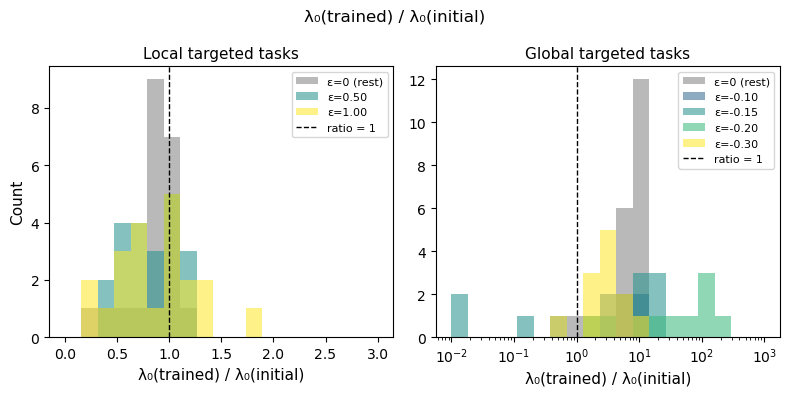

λ₀ ratio histogram saved.


In [ ]:

# ── Plot: overlapping histograms per panel, viridis colored by |ε| ────────────
g_cs_vals = sorted(global_ratios_by_cs.keys(), key=abs)
l_cs_vals  = sorted(local_ratios_by_cs.keys(),  key=abs)

max_g = max((abs(v) for v in g_cs_vals if v != 0.0), default=1.0)
max_l = max((abs(v) for v in l_cs_vals if v != 0.0), default=1.0)
norm_g = Normalize(0, max_g);  norm_l = Normalize(0, max_l)
cmap_v = matplotlib.colormaps['viridis']

fig_l0, (ax_l, ax_g) = plt.subplots(1, 2, figsize=(8, 4))
fig_l0.suptitle('λ₀(trained) / λ₀(initial)', fontsize=12)

for cs_val in l_cs_vals:
    arr = np.array(local_ratios_by_cs[cs_val])
    color = 'gray' if cs_val == 0.0 else cmap_v(norm_l(abs(cs_val)))
    label = 'ε=0 (rest)' if cs_val == 0.0 else f'ε={cs_val:.2f}'
    ax_l.hist(arr, bins=np.linspace(0, 3, 20), alpha=0.55, color=color, edgecolor='none', label=label)
ax_l.axvline(1.0, c='k', lw=1.0, ls='--', label='ratio = 1')
ax_l.set_xlabel('λ₀(trained) / λ₀(initial)', fontsize=11)
ax_l.set_ylabel('Count', fontsize=11)
ax_l.set_title('Local targeted tasks', fontsize=11)
ax_l.legend(fontsize=8)

for cs_val in g_cs_vals:
    arr = np.array(global_ratios_by_cs[cs_val])
    color = 'gray' if cs_val == 0.0 else cmap_v(norm_g(abs(cs_val)))
    label = 'ε=0 (rest)' if cs_val == 0.0 else f'ε={cs_val:.2f}'
    ax_g.hist(arr, bins=np.logspace(-2, 3, 20), alpha=0.55, color=color, edgecolor='none', label=label)
    ax_g.set_xscale('log')
ax_g.axvline(1.0, c='k', lw=1.0, ls='--', label='ratio = 1')
ax_g.set_xlabel('λ₀(trained) / λ₀(initial)', fontsize=11)
ax_g.set_title('Global targeted tasks', fontsize=11)
ax_g.legend(fontsize=8)

fig_l0.tight_layout()
plt.show()
fig_l0.savefig(FIGURE_OUT_DIR / 'lambda0_ratio_hist.pdf', bbox_inches='tight', dpi=150)
print('λ₀ ratio histogram saved.')


## λ₁/λ₂ ratio histogram — local targeted tasks

Histogram of the ratio λ₁/λ₂ (0-indexed: second over third non-trivial Hessian eigenvalue) evaluated at rest (ε=0), comparing **after training** (best-loss checkpoint) vs **before training** (initial stiffnesses), for local targeted tasks.

In [ ]:
from tqdm import tqdm

# ── λ₁/λ₂ ratio histogram — local targeted tasks ─────────────────────────────
# Eigenvalues are 0-indexed from hessian_modes (zero modes already stripped).
# vals[1] = λ₁, vals[2] = λ₂  →  ratio = λ₁/λ₂.
print('=== λ₁/λ₂ ratio histograms (local targeted tasks) ===')

def lambda12_ratio_at_rest_local(task_id, real_id):
    """Return (ratio_trained, ratio_initial) = λ₁/λ₂ at ε=0 before/after training."""
    key = f'june_lambda12ratio_local_t{task_id}_r{real_id}'
    if cache_exists(key) and not FORCE_RECOMPUTE:
        d = load_cache(key)
        return float(d['ratio_trained']), float(d['ratio_initial'])
    nd = load_local_targeted(task_id, real_id)
    if nd is None:
        return np.nan, np.nan
    traj_k_l, _, traj_loss_l = load_local_stiffness_trajectory(task_id, real_id)
    best_l = int(np.argmin(traj_loss_l))
    k_tr, k_in = traj_k_l[best_l], traj_k_l[0]
    vals_tr, _ = hessian_modes(nd['nodes'], k_tr, nd['eq_lengths'], nd['edges'], None)
    vals_in, _ = hessian_modes(nd['nodes'], k_in, nd['eq_lengths'], nd['edges'], None)
    # Guard against near-zero λ₂
    if vals_tr[2] == 0 or vals_in[2] == 0:
        return np.nan, np.nan
    r_tr = float(vals_tr[1] / vals_tr[2])
    r_in = float(vals_in[1] / vals_in[2])
    save_cache(key,
               ratio_trained=np.array(r_tr),
               ratio_initial=np.array(r_in))
    return r_tr, r_in

l12_ratios_trained = []
l12_ratios_initial = []

for task_id in tqdm(PR_LOCAL_TASKS, desc='local tasks'):
    for real_dir in _local_reals(task_id):
        real_id = int(real_dir.name.split('_')[1])
        try:
            r_tr, r_in = lambda12_ratio_at_rest_local(task_id, real_id)
        except Exception as e:
            print(f'  skip task {task_id} real {real_id}: {e}')
            continue
        if np.isfinite(r_tr) and np.isfinite(r_in):
            l12_ratios_trained.append(r_tr)
            l12_ratios_initial.append(r_in)

l12_ratios_trained = np.array(l12_ratios_trained)
l12_ratios_initial = np.array(l12_ratios_initial)
print(f'  Collected {len(l12_ratios_trained)} samples.')


In [ ]:
# ── Plot: λ₁/λ₂ histograms before vs after training ──────────────────────────
fig_l12, ax_l12 = plt.subplots(figsize=(6, 4))

all_vals = np.concatenate([l12_ratios_trained, l12_ratios_initial])
lo, hi = np.nanmin(all_vals), np.nanmax(all_vals)
bins = np.linspace(lo, hi, 30)

ax_l12.hist(l12_ratios_initial, bins=bins, alpha=0.55, color='steelblue',
            edgecolor='none', label='Before training')
ax_l12.hist(l12_ratios_trained, bins=bins, alpha=0.55, color='tomato',
            edgecolor='none', label='After training (best loss)')
ax_l12.axvline(1.0, c='k', lw=1.0, ls='--', label='ratio = 1')
ax_l12.set_xlabel('λ₁ / λ₂  (0-indexed, at rest)', fontsize=11)
ax_l12.set_ylabel('Count', fontsize=11)
ax_l12.set_title('Local targeted tasks — λ₁/λ₂ ratio at ε=0', fontsize=11)
ax_l12.legend(fontsize=9)
fig_l12.tight_layout()
plt.show()
fig_l12.savefig(FIGURE_OUT_DIR / 'lambda12_ratio_hist_local.pdf', bbox_inches='tight', dpi=150)
print('λ₁/λ₂ ratio histogram saved.')
